In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def parse_numeric_value(value):
    """Convierte valores numéricos de exportaciones Fiji a float, tolerando texto vacío."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return float(value)
    if isinstance(value, str):
        text = value.strip().replace(",", ".")
        if text in {"", "nan", "NaN", "None", "none", "N/A", "n/a"}:
            return np.nan
        try:
            return float(text)
        except ValueError:
            return np.nan
    return np.nan


def detectar_columnas_roi(df):
    """Identifica columnas de ROI en archivos exportados desde Fiji u ODS/CSV."""
    cols = []
    for col in df.columns:
        col_str = str(col).strip().lower()
        if col_str == "frame":
            continue
        if "mean" in col_str:
            cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            cols.append(col)
    if not cols and len(df.columns) > 1:
        cols = [col for col in df.columns if str(col).strip().lower() != "frame"]
    return cols


def normalizar_nombres_roi(df):
    """Convierte columnas como dF_F0_Mean1 a dF_F0_ROI1 cuando sea necesario."""
    if df is None:
        return df

    rename_map = {}
    for col in df.columns:
        if col.startswith("dF_F0_Mean"):
            suffix = col.replace("dF_F0_Mean", "", 1)
            if suffix.isdigit():
                target = f"dF_F0_ROI{suffix}"
                if target not in df.columns:
                    rename_map[col] = target

    if rename_map:
        df = df.rename(columns=rename_map)

    return df


def crear_excel_analisis(ruta_archivo, n_baseline=30, guardar_grafico=True):
    """Carga un archivo, convierte a dF/F0 por ROI y guarda un Excel de análisis."""
    ruta_archivo = Path(ruta_archivo)
    raw_df = cargar_archivo(ruta_archivo)

    if "Frame" not in raw_df.columns:
        if len(raw_df.columns) > 0:
            raw_df = raw_df.rename(columns={raw_df.columns[0]: "Frame"})
        else:
            raise ValueError("El archivo no contiene columnas para procesar.")

    raw_df["Frame"] = pd.to_numeric(raw_df["Frame"], errors="coerce")
    if raw_df["Frame"].isna().any():
        raise ValueError("La columna de frames no se pudo convertir a numérico.")

    roi_cols = detectar_columnas_roi(raw_df)
    if not roi_cols:
        raise ValueError("No se encontraron columnas de ROI para procesar.")

    analisis = pd.DataFrame({"Frame": raw_df["Frame"]})
    roi_counter = 1
    for col in roi_cols:
        serie = raw_df[col].astype(str).apply(parse_numeric_value)
        baseline = serie.iloc[: min(n_baseline, len(serie))].mean()
        if baseline == 0 or np.isnan(baseline):
            continue
        roi_name = f"dF_F0_ROI{roi_counter}"
        analisis[roi_name] = (serie - baseline) / baseline
        roi_counter += 1

    analisis = normalizar_nombres_roi(analisis)

    carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
    carpeta_salida.mkdir(exist_ok=True, parents=True)
    ruta_excel = carpeta_salida / f"{ruta_archivo.stem}_analisis_roi.xlsx"
    analisis.to_excel(ruta_excel, index=False)

    resumen = pd.DataFrame(
        {
            "Archivo": [ruta_archivo.name],
            "Frames": [len(analisis)],
            "ROIs": [sum(1 for c in analisis.columns if c.startswith("dF_F0_"))],
        }
    )
    resumen.to_excel(carpeta_salida / f"{ruta_archivo.stem}_resumen.xlsx", index=False)

    if guardar_grafico:
        for roi_col in [c for c in analisis.columns if c.startswith("dF_F0_")]:
            plt.figure(figsize=(10, 3))
            plt.plot(analisis["Frame"], analisis[roi_col], color="tab:blue")
            plt.title(f"{roi_col}")
            plt.xlabel("Frame")
            plt.ylabel("dF/F0")
            plt.tight_layout()
            plt.close()

    return str(carpeta_salida), analisis, resumen


def cargar_archivo(ruta_archivo):
    """
    Carga un archivo exportado desde Fiji.
    Acepta .xlsx, .xls, .ods o .csv.
    """
    ruta_archivo = Path(ruta_archivo)
    suffix = ruta_archivo.suffix.lower()

    if suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(ruta_archivo)
    elif suffix == ".ods":
        try:
            df = pd.read_excel(ruta_archivo, engine="odf")
        except ValueError as e:
            raise ValueError(
                "No se puede leer el archivo .ods. Instala odfpy con 'pip install odfpy' "
                "y vuelve a intentarlo."
            ) from e
    elif suffix == ".csv":
        try:
            df = pd.read_csv(
                ruta_archivo,
                sep=None,
                engine="python",
                skipinitialspace=True,
            )
        except Exception:
            df = pd.read_csv(
                ruta_archivo,
                sep=",",
                engine="python",
                skipinitialspace=True,
            )
    else:
        raise ValueError("Formato no soportado. Usa .xlsx, .xls, .ods o .csv")

    for col in df.columns:
        if "mean" in str(col).lower():
            df[col] = df[col].astype(str).apply(parse_numeric_value)

    return df


In [ ]:
def analizar_pre_peak(
    analisis,
    roi,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=2.0,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=False,
):
    """
    Detecta el peak principal y microeventos antes de ese peak.
    Prioriza el peak más fuerte y posterior a la línea basal.
    """
    if roi not in analisis.columns:
        raise ValueError(
            f"La ROI '{roi}' no existe en el DataFrame. Columnas disponibles: {list(analisis.columns)}"
        )

    df = analisis[["Frame", roi]].copy()
    df["senal_suavizada"] = df[roi].rolling(
        ventana_suavizado, center=True, min_periods=1
    ).mean()

    signal = df["senal_suavizada"].to_numpy(dtype=float)
    baseline = signal[: min(n_baseline, len(signal))]
    media_basal = np.nanmean(baseline)
    std_basal = np.nanstd(baseline)
    peak_threshold = media_basal + umbral_factor * std_basal

    if len(signal) < 3:
        peak_index = int(np.nanargmax(signal))
    else:
        local_maxima = [
            i,
            for i in range(1, len(signal) - 1)
            if signal[i] >= signal[i - 1] and signal[i] >= signal[i + 1],
        ]

        if not local_maxima:
            peak_index = int(np.nanargmax(signal))
        else:
            candidates = [i for i in local_maxima if i >= n_baseline]
            if candidates:
                above_threshold = [i for i in candidates if signal[i] >= peak_threshold]
                if above_threshold:
                    dominant_peak_value = max(signal[i] for i in above_threshold)
                    min_significant = max(peak_threshold, dominant_peak_value * 0.33)
                    significant_peaks = [i for i in above_threshold if signal[i] >= min_significant]
                    if significant_peaks:
                        peak_index = max(significant_peaks, key=lambda i: signal[i])
                    else:
                        peak_index = max(above_threshold, key=lambda i: signal[i])
                else:
                    peak_index = max(candidates, key=lambda i: signal[i])
            else:
                peak_index = int(np.nanargmax(signal))

    frame_peak = int(df.loc[peak_index, "Frame"])

    if peak_index == 0 and len(signal) > 5:
        later_peak_index = int(np.nanargmax(signal[1:])) + 1
        if signal[later_peak_index] >= 0.8 * signal[0]:
            peak_index = later_peak_index
            frame_peak = int(df.loc[peak_index, "Frame"])

    pre_peak = df[df["Frame"] < frame_peak].copy()

    baseline_pre_peak = pre_peak.iloc[: min(n_baseline, len(pre_peak))]["senal_suavizada"]
    media_basal_pre_peak = baseline_pre_peak.mean()
    std_basal_pre_peak = baseline_pre_peak.std()
    umbral_pre_peak = media_basal_pre_peak + umbral_factor * std_basal_pre_peak

    pre_peak["sobre_umbral"] = pre_peak["senal_suavizada"] > umbral_pre_peak
    candidatos = pre_peak[pre_peak["sobre_umbral"]].copy()

    eventos = []
    estado_activo = False
    inicio_evento = None

    for _, row in pre_peak.iterrows():
        if row["sobre_umbral"] and not estado_activo:
            estado_activo = True
            inicio_evento = int(row["Frame"])
        elif not row["sobre_umbral"] and estado_activo:
            fin_evento = int(row["Frame"] - 1)
            duracion = fin_evento - inicio_evento + 1
            if duracion >= min_frames:
                eventos.append((inicio_evento, fin_evento, duracion))
            estado_activo = False
            inicio_evento = None

    if estado_activo and inicio_evento is not None:
        fin_evento = int(pre_peak["Frame"].iloc[-1])
        duracion = fin_evento - inicio_evento + 1
        if duracion >= min_frames:
            eventos.append((inicio_evento, fin_evento, duracion))

    if mostrar:
        print(f"ROI: {roi}")
        print(f"Frame_peak: {frame_peak}")
        print(f"Umbral: {peak_threshold}")
        print(f"Media basal: {media_basal}")
        print(f"Std basal: {std_basal}")
        print(df.head(20))

    return {
        "roi": roi,
        "frame_peak": frame_peak,
        "peak_index": peak_index,
        "umbral_peak": peak_threshold,
        "media_basal": media_basal,
        "std_basal": std_basal,
        "eventos": eventos,
        "n_eventos": len(eventos),
        "duracion_promedio": np.mean([e[2] for e in eventos]) if eventos else np.nan,
        "amplitud_maxima": float(np.nanmax(signal)) if len(signal) else np.nan,
    }


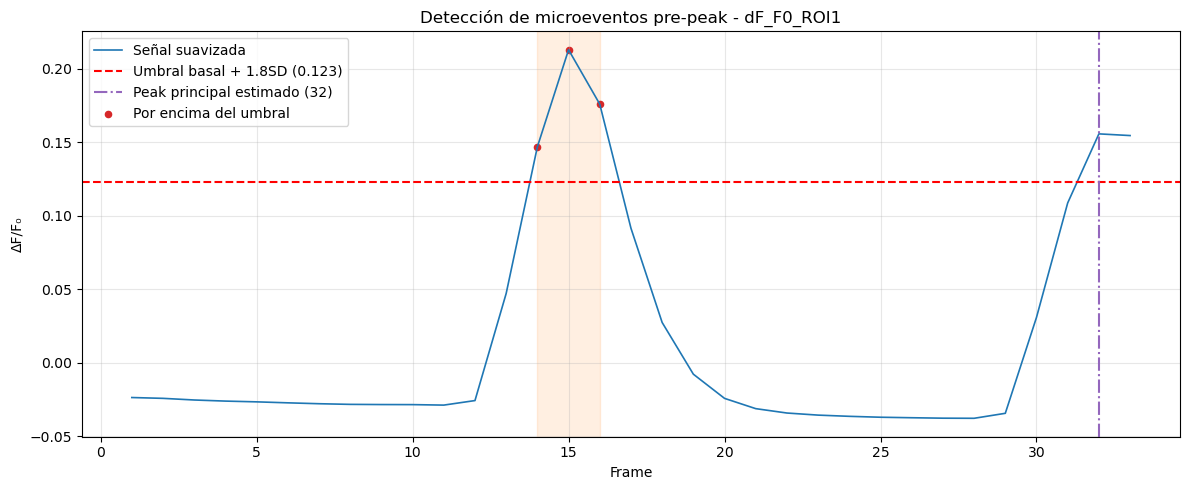

Frame del peak principal: 32
Umbral basal + 2SD (factor usado): 0.1229

Resumen de eventos robustos antes del peak:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0      14   16         3          15    0.212882           0.210831


In [7]:
import matplotlib.pyplot as plt

# Usa una ROI disponible en el DataFrame
roi = "dF_F0_ROI1"

# Recalcula siempre el análisis para evitar reutilizar una tabla vieja con nombres incompatibles
ruta_salida, analisis, resumen = crear_excel_analisis(
    ruta_archivo="Results 14DIV_GCamp-NLS-jRGECO1aASX162_w1Channel-B.csv",
    n_baseline=30,
    guardar_grafico=True,
)
df_dff = normalizar_nombres_roi(analisis)

resultado = analizar_pre_peak(
    df_dff,
    roi=roi,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    mostrar=True,
)

print("Frame del peak principal:", resultado["frame_peak"])
print("Umbral basal + 2SD (factor usado):", round(resultado["umbral"], 4))
print("\nResumen de eventos robustos antes del peak:")
print(resultado["resumen_eventos"])

if resultado["resumen_eventos"].empty:
    print("\nNo se encontraron eventos robustos. Se muestran candidatos por encima del umbral:")
    print(resultado["eventos_candidatos"]["Frame"].to_frame().assign(valor=resultado["eventos_candidatos"][roi]))


ROIs excluidas: ['dF_F0_ROI8']
Tablas de eventos pre-peak actualizadas automáticamente.
Archivo pre-peak guardado en: Results_15DIV_double-sequential-ASX21_w1Channel-B\Results_15DIV_double-sequential-ASX21_w1Channel-B_pre_peak.xlsx

Resumen general pre-peak:
          ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0  dF_F0_ROI1          13  0.003440     0.001633   0.001004             0   
1  dF_F0_ROI2         163  0.004569    -0.000008   0.002542            12   
2  dF_F0_ROI3           2       NaN     0.024243        NaN             0   
3  dF_F0_ROI4          22  0.003823     0.000729   0.001719             1   
4  dF_F0_ROI5         148  0.007808    -0.000004   0.004340             4   
5  dF_F0_ROI6          47  0.009915     0.000003   0.005507             2   
6  dF_F0_ROI7         150  0.005285     0.000002   0.002935             3   

   N_eventos_robustos  
0                   0  
1                   2  
2                   0  
3                   0  
4   

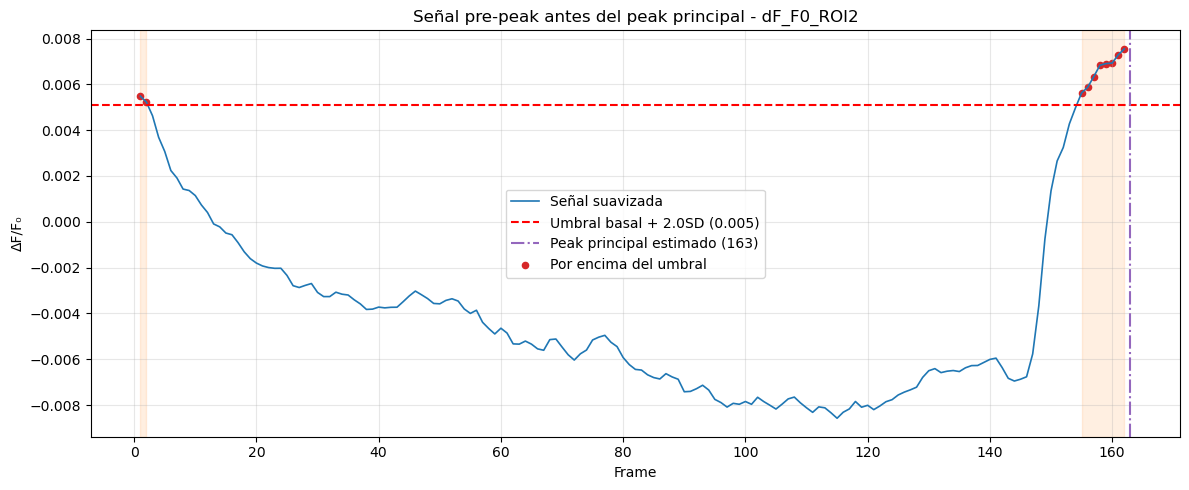

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0       1    2         2           1    0.005487           0.005495
1     155  162         8         162    0.007552           0.007560


In [11]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def exportar_tablas_eventos_pre_peak(
    archivo,
    resumen_df=None,
    eventos_df=None,
    ruta_detalle="tabla_eventos_pre_peak.xlsx",
    ruta_resumen="tabla_eventos_pre_peak_resumen.xlsx",
):
    """Crea o actualiza las tablas detallada y resumen de eventos pre-peak."""
    ruta_detalle = Path(ruta_detalle)
    ruta_resumen = Path(ruta_resumen)
    ruta_detalle.parent.mkdir(exist_ok=True, parents=True)
    ruta_resumen.parent.mkdir(exist_ok=True, parents=True)

    columnas_detalle = [
        "Archivo",
        "ROI",
        "Frame peak",
        "Eventos pre-peak",
        "Frame inicio evento",
        "Duración",
        "Pico del evento",
        "Amplitud",
    ]
    columnas_resumen = [
        "Archivo",
        "ROIs evaluadas",
        "ROIs con eventos",
        "Total eventos pre-peak",
        "Duración promedio",
        "Amplitud máxima",
    ]

    if resumen_df is None or resumen_df.empty:
        resumen_df = pd.DataFrame(columns=["ROI", "Frame_peak", "N_eventos_robustos"])
    else:
        resumen_df = resumen_df.copy()

    if eventos_df is None or eventos_df.empty:
        detalle_df = pd.DataFrame(columns=columnas_detalle)
        resumen_archivo_df = pd.DataFrame(columns=columnas_resumen)
    else:
        eventos_df = eventos_df.copy()
        if "ROI" not in eventos_df.columns:
            raise ValueError("El DataFrame de eventos debe tener la columna 'ROI'.")

        conteos = (
            eventos_df.groupby("ROI")
            .size()
            .rename("N_eventos_robustos")
            .reset_index()
        )
        resumen_join = resumen_df[["ROI", "Frame_peak"]].merge(conteos, on="ROI", how="left")
        resumen_join["N_eventos_robustos"] = resumen_join["N_eventos_robustos"].fillna(0).astype(int)

        detalle_df = eventos_df.merge(
            resumen_join[["ROI", "Frame_peak", "N_eventos_robustos"]],
            on="ROI",
            how="left",
        )
        detalle_df["Archivo"] = Path(archivo).name if archivo is not None else ""
        detalle_df["Frame peak"] = detalle_df["Frame_peak"]
        detalle_df["Eventos pre-peak"] = detalle_df["N_eventos_robustos"]
        detalle_df["Frame inicio evento"] = detalle_df["inicio"]
        detalle_df["Duración"] = detalle_df["duracion"]
        detalle_df["Pico del evento"] = detalle_df["pico_frame"]
        detalle_df["Amplitud"] = detalle_df["amplitud_vs_basal"]
        detalle_df = detalle_df[columnas_detalle]

        rois_evaluadas = len(resumen_df)
        rois_con_eventos = int(eventos_df["ROI"].nunique())
        total_eventos = int(len(eventos_df))
        duracion_promedio = float(eventos_df["duracion"].mean()) if not eventos_df.empty else 0.0
        amplitud_maxima = float(eventos_df["amplitud_vs_basal"].max()) if not eventos_df.empty else 0.0
        resumen_archivo_df = pd.DataFrame(
            [
                {
                    "Archivo": Path(archivo).name if archivo is not None else "",
                    "ROIs evaluadas": rois_evaluadas,
                    "ROIs con eventos": rois_con_eventos,
                    "Total eventos pre-peak": total_eventos,
                    "Duración promedio": duracion_promedio,
                    "Amplitud máxima": amplitud_maxima,
                }
            ],
            columns=columnas_resumen,
        )

    detalle_df.to_excel(ruta_detalle, index=False)
    resumen_archivo_df.to_excel(ruta_resumen, index=False)
    return detalle_df, resumen_archivo_df


def procesar_pre_peak_todas(analisis, n_baseline=30, ventana_suavizado=3, umbral_factor=2.0, min_frames=2, exclude_rois=None):
    """
    Procesa todas las ROIs de dF/F0 para extraer información pre-peak.
    Devuelve un resumen general, eventos robustos, candidatos y datos pre-peak por ROI.
    """
    if exclude_rois is None:
        exclude_rois = []

    roi_cols = [col for col in analisis.columns if col.startswith("dF_F0_") and col not in exclude_rois]
    resumen = []
    eventos_pre_peak = []
    candidatos_pre_peak = []
    pre_peak_signales = {}

    for roi in roi_cols:
        resultado = analizar_pre_peak(
            analisis,
            roi=roi,
            n_baseline=n_baseline,
            ventana_suavizado=ventana_suavizado,
            umbral_factor=umbral_factor,
            min_frames=min_frames,
            mostrar=False,
        )

        resumen.append({
            "ROI": roi,
            "Frame_peak": resultado["frame_peak"],
            "Umbral": resultado["umbral"],
            "Media_basal": resultado["media_basal"],
            "Std_basal": resultado["std_basal"],
            "N_candidatos": len(resultado["eventos_candidatos"]),
            "N_eventos_robustos": len(resultado["resumen_eventos"]),
        })

        if not resultado["resumen_eventos"].empty:
            eventos = resultado["resumen_eventos"].copy()
            eventos.insert(0, "ROI", roi)
            eventos_pre_peak.append(eventos)

        if not resultado["eventos_candidatos"].empty:
            candidatos = resultado["eventos_candidatos"].copy()
            candidatos.insert(0, "ROI", roi)
            candidatos_pre_peak.append(candidatos)

        pre_peak = resultado["pre_peak"].copy()
        pre_peak.insert(0, "ROI", roi)
        pre_peak_signales[roi] = pre_peak

    resumen_df = pd.DataFrame(resumen)

    if eventos_pre_peak:
        eventos_df = pd.concat(eventos_pre_peak, ignore_index=True)
    else:
        eventos_df = pd.DataFrame(
            columns=["ROI", "inicio", "fin", "duracion", "pico_frame", "pico_valor", "amplitud_vs_basal"]
        )

    if candidatos_pre_peak:
        candidatos_df = pd.concat(candidatos_pre_peak, ignore_index=True)
    else:
        candidatos_df = pd.DataFrame(columns=["ROI", "Frame", "senal_suavizada", "sobre_umbral"])

    return resumen_df, eventos_df, candidatos_df, pre_peak_signales


def guardar_pre_peak_excel(ruta_archivo, carpeta_salida, resumen_df, eventos_df, candidatos_df, pre_peak_signales):
    """
    Guarda un archivo Excel con el análisis pre-peak por ROI.
    """
    ruta_archivo = Path(ruta_archivo)
    ruta_pre_peak = carpeta_salida / (ruta_archivo.stem + "_pre_peak.xlsx")

    with pd.ExcelWriter(ruta_pre_peak, engine="openpyxl") as writer:
        resumen_df.to_excel(writer, sheet_name="Resumen_PrePeak", index=False)
        eventos_df.to_excel(writer, sheet_name="Eventos_PrePeak", index=False)
        candidatos_df.to_excel(writer, sheet_name="Candidatos_PrePeak", index=False)

        def _sanitize_sheet_name(name, existing_names):
            invalid_chars = set('[]:*?/\\')
            safe = ''.join("_" if c in invalid_chars else c for c in name)
            safe = safe[:31].strip() or "Sheet"
            candidate = safe
            suffix = 1
            while candidate in existing_names:
                suffix_str = f"_{suffix}"
                candidate = safe[: 31 - len(suffix_str)] + suffix_str
                suffix += 1
            existing_names.add(candidate)
            return candidate

        used_sheet_names = {
            "Resumen_PrePeak",
            "Eventos_PrePeak",
            "Candidatos_PrePeak",
        }

        for roi, df_pre in pre_peak_signales.items():
            nombre_hoja = f"PrePeak_{roi}"
            hoja_segura = _sanitize_sheet_name(nombre_hoja, used_sheet_names)
            df_pre.to_excel(writer, sheet_name=hoja_segura, index=False)

    try:
        exportar_tablas_eventos_pre_peak(
            archivo=ruta_archivo,
            resumen_df=resumen_df,
            eventos_df=eventos_df,
            ruta_detalle="tabla_eventos_pre_peak.xlsx",
            ruta_resumen="tabla_eventos_pre_peak_resumen.xlsx",
        )
        print("Tablas de eventos pre-peak actualizadas automáticamente.")
    except Exception as err:
        print(f"No se pudieron actualizar las tablas de eventos automáticamente: {err}")

    print(f"Archivo pre-peak guardado en: {ruta_pre_peak}")
    return ruta_pre_peak


# Nuevo archivo a procesar
archivo_nuevo = "Results_15DIV_double-sequential-ASX21_w1Channel-B.csv"
ruta_archivo = Path(archivo_nuevo)

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_candidates = [c for c in analisis_nuevo.columns if c.startswith("dF_F0_") and c != "Frame"]
roi_elegida = roi_candidates[1] if len(roi_candidates) > 1 else (roi_candidates[0] if roi_candidates else None)
if roi_elegida is None:
    raise ValueError("No hay columnas de ROI disponibles para graficar.")
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])


ROIs excluidas: ['dF_F0_ROI8']
Tablas de eventos pre-peak actualizadas automáticamente.
Archivo pre-peak guardado en: Results_15DIV_double-sequential-ASX21_w1Channel-B\Results_15DIV_double-sequential-ASX21_w1Channel-B_pre_peak.xlsx

Resumen general pre-peak:
          ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0  dF_F0_ROI1          13  0.003440     0.001633   0.001004             0   
1  dF_F0_ROI2         163  0.004569    -0.000008   0.002542            12   
2  dF_F0_ROI3           2       NaN     0.024243        NaN             0   
3  dF_F0_ROI4          22  0.003823     0.000729   0.001719             1   
4  dF_F0_ROI5         148  0.007808    -0.000004   0.004340             4   
5  dF_F0_ROI6          47  0.009915     0.000003   0.005507             2   
6  dF_F0_ROI7         150  0.005285     0.000002   0.002935             3   

   N_eventos_robustos  
0                   0  
1                   2  
2                   0  
3                   0  
4   

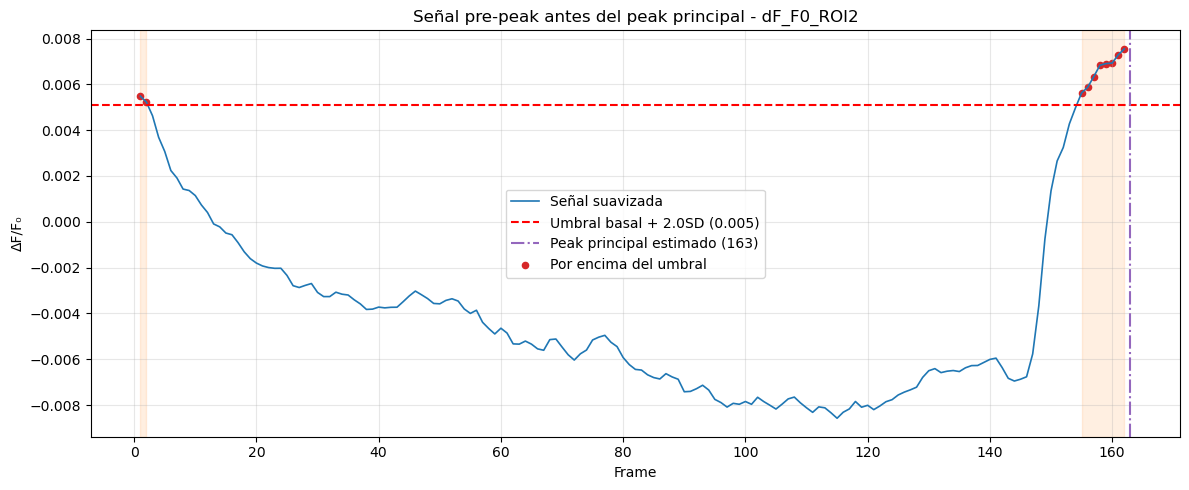

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0       1    2         2           1    0.005487           0.005495
1     155  162         8         162    0.007552           0.007560


In [12]:
# Nuevo archivo a procesar
archivo_nuevo = "Results_15DIV_double-sequential-ASX21_w1Channel-B.csv"
ruta_archivo = Path(archivo_nuevo)

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI2"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])


Gráfico guardado en: Results_15DIV_double-sequential-ASX21_w1Channel-B\Results_15DIV_double-sequential-ASX21_w1Channel-B_grafico_dF_F0.png
Archivo analizado creado correctamente:
Results_15DIV_double-sequential-ASX21_w1Channel-B\Results_15DIV_double-sequential-ASX21_w1Channel-B_analisis_roi.xlsx

Columnas Mean detectadas:
- Mean1
- Mean2
- Mean3
- Mean4
- Mean5
- Mean6
- Mean7
- Mean8
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: Results_15DIV_double-sequential-ASX21_w1Channel-B\Results_15DIV_double-sequential-ASX21_w1Channel-B_pre_peak.xlsx

Resumen general pre-peak:
          ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0  dF_F0_ROI1          13  0.003440     0.001633   0.001004             0   
1  dF_F0_ROI2         163  0.004569    -0.000008   0.002542            12   
2  dF_F0_ROI3           2       NaN     0.024243        NaN             0   
3  dF_F0_ROI4          22  0.003823     0.000729   0.001719             1   
4  dF_F0_ROI5         148

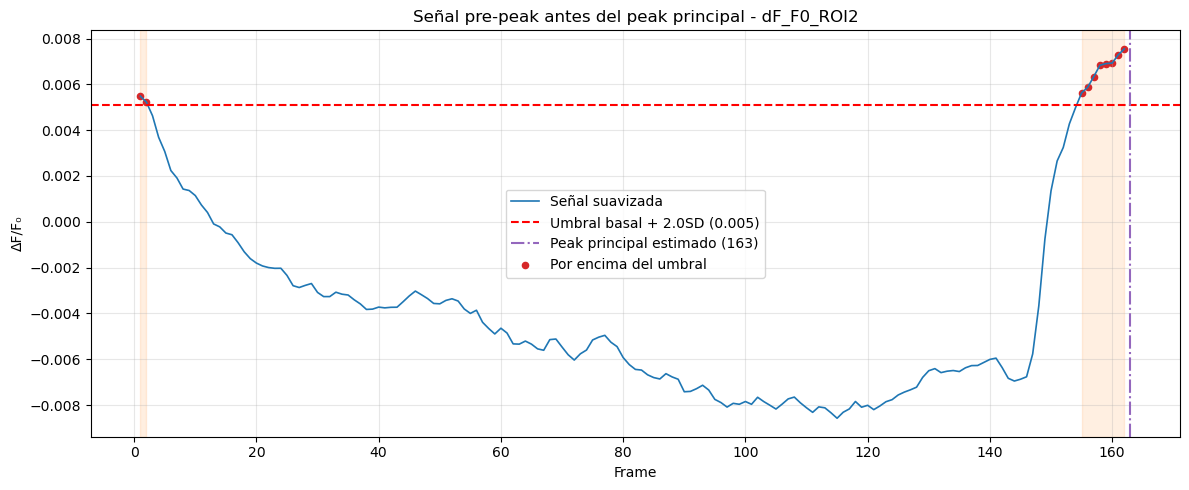

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0       1    2         2           1    0.005487           0.005495
1     155  162         8         162    0.007552           0.007560


In [ ]:
# Nuevo archivo a procesar
archivo_nuevo = "Results_15DIV_double-sequential-ASX21_w1Channel-B.csv"
ruta_archivo = Path(archivo_nuevo)

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI2"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])


Gráfico guardado en: 14DIV_GCaMP6-NLS-NMDA_control 4_Channel\14DIV_GCaMP6-NLS-NMDA_control 4_Channel_grafico_dF_F0.png
Archivo analizado creado correctamente:
14DIV_GCaMP6-NLS-NMDA_control 4_Channel\14DIV_GCaMP6-NLS-NMDA_control 4_Channel_analisis_roi.xlsx

Columnas Mean detectadas:
- ROI1
- ROI2
- ROI3
- ROI4
- ROI5
- ROI6
- ROI7
- ROI8
- ROI9
- ROI10
- ROI11
- ROI12
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: 14DIV_GCaMP6-NLS-NMDA_control 4_Channel\14DIV_GCaMP6-NLS-NMDA_control 4_Channel_pre_peak.xlsx

Resumen general pre-peak:
            ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0    dF_F0_ROI1         469  0.000279    -0.000003   0.000157           212   
1    dF_F0_ROI2         107  0.000599    -0.000001   0.000333            15   
2    dF_F0_ROI3         458  0.001046    -0.000008   0.000585            26   
3    dF_F0_ROI4         457  0.000473    -0.000002   0.000264            10   
4    dF_F0_ROI5         473  0.001693     0.000003  

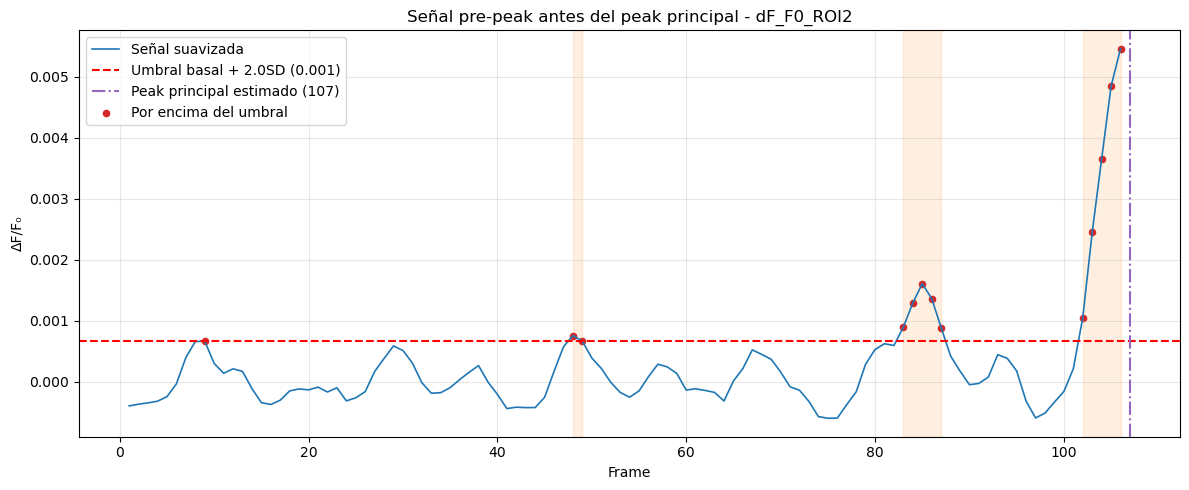

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0      48   49         2          48    0.000760           0.000761
1      83   87         5          85    0.001610           0.001612
2     102  106         5         106    0.005458           0.005459


In [ ]:
# Archivo entregado en otro formato
archivo_nuevo = "14DIV_GCaMP6-NLS-NMDA_control 4_Channel.ods"
ruta_archivo = Path(archivo_nuevo)

# Ajuste de detección de columnas para el formato nuevo
# Este archivo tiene encabezados ROI1, ROI2, ... en lugar de Mean.
def detectar_columnas_mean(df):
    mean_cols = []
    for col in df.columns:
        col_str = str(col).lower()
        if "mean" in col_str:
            mean_cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            mean_cols.append(col)

    if len(mean_cols) == 0:
        raise ValueError(
            "No se encontraron columnas con 'Mean' ni encabezados 'ROI'. "
            "Revisa el formato del archivo."
        )
    return mean_cols

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI2"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])


Gráfico guardado en: 14DIV_GCaMP6-NLS-NMDA_control2_Channel-B\14DIV_GCaMP6-NLS-NMDA_control2_Channel-B_grafico_dF_F0.png
Archivo analizado creado correctamente:
14DIV_GCaMP6-NLS-NMDA_control2_Channel-B\14DIV_GCaMP6-NLS-NMDA_control2_Channel-B_analisis_roi.xlsx

Columnas Mean detectadas:
- ROI1
- ROI2
- ROI3
- ROI4
- ROI5
- ROI6
- ROI7
- ROI8
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: 14DIV_GCaMP6-NLS-NMDA_control2_Channel-B\14DIV_GCaMP6-NLS-NMDA_control2_Channel-B_pre_peak.xlsx

Resumen general pre-peak:
          ROI  Frame_peak    Umbral   Media_basal  Std_basal  N_candidatos  \
0  dF_F0_ROI1         268  0.000569 -4.407585e-07   0.000316            11   
1  dF_F0_ROI2         273  0.000608  3.585326e-06   0.000336            84   
2  dF_F0_ROI3         272  0.000661  6.962588e-06   0.000363            20   
3  dF_F0_ROI4         270  0.001663  5.746605e-06   0.000921            18   
4  dF_F0_ROI5         271  0.000426  2.618105e-06   0.000235            15   
5  d

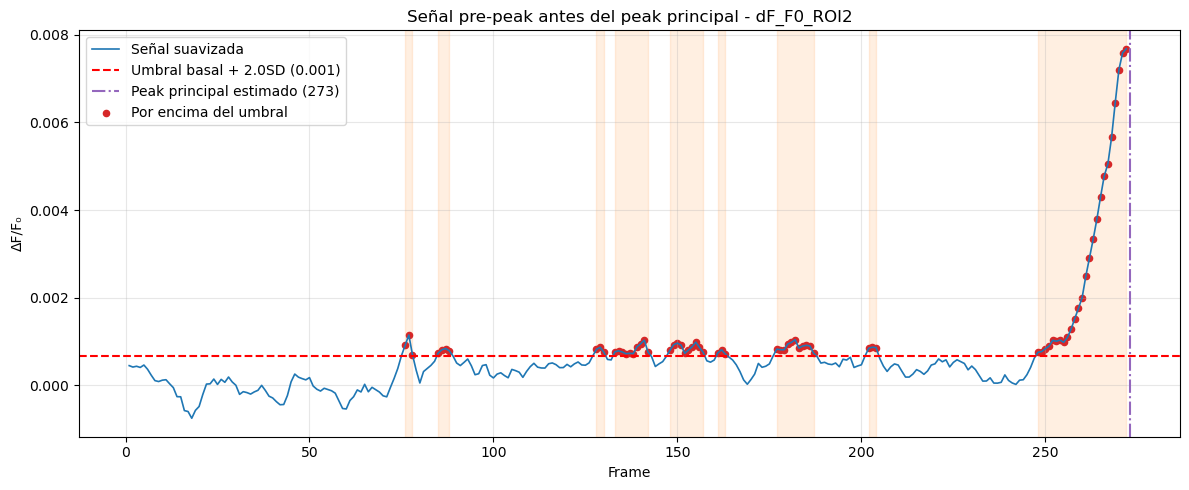

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0      76   78         3          77    0.001146           0.001143
1      85   88         4          87    0.000838           0.000834
2     128  130         3         129    0.000865           0.000861
3     133  142        10         141    0.001028           0.001025
4     148  157        10         155    0.000984           0.000980
5     161  163         3         162    0.000809           0.000805
6     177  187        11         182    0.001040           0.001036
7     202  204         3         203    0.000868           0.000864
8     248  272        25         272    0.007681           0.007678


In [ ]:
# Archivo entregado en otro formato
archivo_nuevo = "14DIV_GCaMP6-NLS-NMDA_control2_Channel-B.ods"
ruta_archivo = Path(archivo_nuevo)

# Ajuste de detección de columnas para el formato nuevo
# Este archivo tiene encabezados ROI1, ROI2, ... en lugar de Mean.
def detectar_columnas_mean(df):
    mean_cols = []
    for col in df.columns:
        col_str = str(col).lower()
        if "mean" in col_str:
            mean_cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            mean_cols.append(col)

    if len(mean_cols) == 0:
        raise ValueError(
            "No se encontraron columnas con 'Mean' ni encabezados 'ROI'. "
            "Revisa el formato del archivo."
        )
    return mean_cols

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI2"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])

Gráfico guardado en: 14DIV_GCamp-NLS-jRGECO1a control21\14DIV_GCamp-NLS-jRGECO1a control21_grafico_dF_F0.png
Archivo analizado creado correctamente:
14DIV_GCamp-NLS-jRGECO1a control21\14DIV_GCamp-NLS-jRGECO1a control21_analisis_roi.xlsx

Columnas Mean detectadas:
- ROI1
- ROI2
- ROI3
- ROI4
- ROI5
- ROI6
- ROI7
- ROI8
- ROI9
- ROI10
- ROI11
- ROI12
- ROI13
- ROI14
- ROI15
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: 14DIV_GCamp-NLS-jRGECO1a control21\14DIV_GCamp-NLS-jRGECO1a control21_pre_peak.xlsx

Resumen general pre-peak:
            ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0    dF_F0_ROI1         151  0.010096    -0.000003   0.005610             4   
1    dF_F0_ROI2         151  0.014968    -0.000009   0.008320             5   
2    dF_F0_ROI3         150  0.015846    -0.000015   0.008812             9   
3    dF_F0_ROI4         150  0.004446     0.000005   0.002467             9   
4    dF_F0_ROI5         150  0.006966    -0.000015   0.003

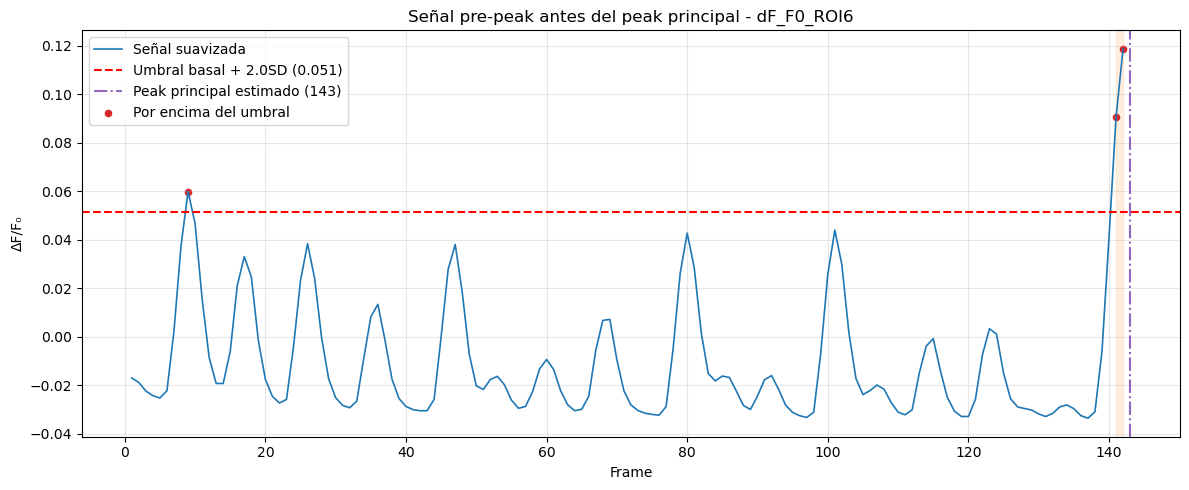

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0     141  142         2         142    0.118736           0.118793


In [ ]:
# Archivo entregado en otro formato
archivo_nuevo = "14DIV_GCamp-NLS-jRGECO1a control21.ods"
ruta_archivo = Path(archivo_nuevo)

# Ajuste de detección de columnas para el formato nuevo
# Este archivo tiene encabezados ROI1, ROI2, ... en lugar de Mean.
def detectar_columnas_mean(df):
    mean_cols = []
    for col in df.columns:
        col_str = str(col).lower()
        if "mean" in col_str:
            mean_cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            mean_cols.append(col)

    if len(mean_cols) == 0:
        raise ValueError(
            "No se encontraron columnas con 'Mean' ni encabezados 'ROI'. "
            "Revisa el formato del archivo."
        )
    return mean_cols

# Ejecutar el análisis principal (crea carpeta y archivo Excel con dF/F0)
ruta_salida_nuevo, analisis_nuevo, resumen_nuevo = crear_excel_analisis(
    ruta_archivo=archivo_nuevo,
    n_baseline=30,
    guardar_grafico=True,
)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI6"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])

Análisis dF/F0 generado en: 14DIV_GCamp-NLS-jRGECO1aASX11_w1Channel-B\14DIV_GCamp-NLS-jRGECO1aASX11_w1Channel-B_analisis_roi.xlsx
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: 14DIV_GCamp-NLS-jRGECO1aASX11_w1Channel-B\14DIV_GCamp-NLS-jRGECO1aASX11_w1Channel-B_pre_peak.xlsx

Resumen general pre-peak:
           ROI  Frame_peak    Umbral  Media_basal  Std_basal  N_candidatos  \
0   dF_F0_ROI1           3  0.003418     0.003000   0.000232             0   
1   dF_F0_ROI2         228  0.004440     0.000014   0.002459            19   
2   dF_F0_ROI3           3  0.002875     0.002575   0.000167             0   
3   dF_F0_ROI4           3  0.004228     0.003698   0.000294             0   
4   dF_F0_ROI5         173  0.000715     0.000014   0.000390            87   
5   dF_F0_ROI6           3  0.001842     0.001499   0.000191             0   
6   dF_F0_ROI7           3  0.001328     0.001088   0.000133             0   
7   dF_F0_ROI9         150  0.002506    -0.000010   0.001397

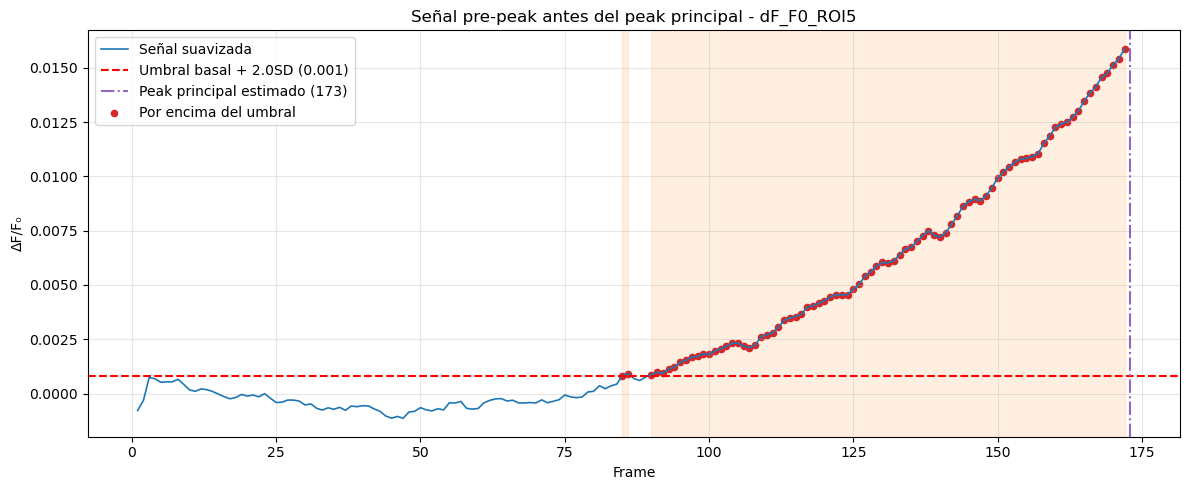

Resumen de la ROI seleccionada:
   inicio  fin  duracion  pico_frame  pico_valor  amplitud_vs_basal
0      85   86         2          86     0.00092           0.000906
1      90  172        83         172     0.01587           0.015856


In [ ]:
# Archivo entregado en otro formato
archivo_nuevo = "14DIV_GCamp-NLS-jRGECO1aASX11_w1Channel-B.ods"
ruta_archivo = Path(archivo_nuevo)

# Ajuste de detección de columnas para el formato nuevo
# Este archivo tiene encabezados ROI1, ROI2, ... en lugar de Mean.
def detectar_columnas_mean(df):
    mean_cols = []
    for col in df.columns:
        col_str = str(col).lower()
        if "mean" in col_str:
            mean_cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            mean_cols.append(col)

    if len(mean_cols) == 0:
        raise ValueError(
            "No se encontraron columnas con 'Mean' ni encabezados 'ROI'. "
            "Revisa el formato del archivo."
        )
    return mean_cols

# Cargar el archivo .ods y convertir los valores de ROI a numérico
raw_df = cargar_archivo(ruta_archivo)
if "Frame" not in raw_df.columns:
    raw_df = raw_df.rename(columns={raw_df.columns[0]: "Frame"})
raw_df["Frame"] = pd.to_numeric(raw_df["Frame"], errors="coerce")
if raw_df["Frame"].isna().any():
    raise ValueError("La columna de frames no se pudo convertir a numérico.")

roi_raw_cols = detectar_columnas_mean(raw_df)
analisis_nuevo = pd.DataFrame({"Frame": raw_df["Frame"]})

# Construir dF/F0 y asegurar nombres consistentes de ROI
for i, col in enumerate(roi_raw_cols, start=1):
    # Si la columna original no existe (caso raro), intentamos por posición
    if col in raw_df.columns:
        serie = raw_df[col].astype(str).apply(parse_numeric_value)
        raw_col_label = str(col)
    else:
        # fallback: tomar la i-ésima columna (después de Frame)
        raw_col = raw_df.columns[i]
        serie = raw_df[raw_col].astype(str).apply(parse_numeric_value)
        raw_col_label = str(raw_col)

    baseline = serie.iloc[:30].mean()
    if baseline == 0 or np.isnan(baseline):
        raise ValueError(f"No se puede calcular baseline para la columna {raw_col_label}")

    # Normalizar etiqueta de ROI (ROI1, ROI2, ...)
    if str(raw_col_label).strip().lower().startswith("unnamed") or not str(raw_col_label).strip():
        roi_label = f"ROI{i}"
    else:
        # limpiar espacios y caracteres no deseados
        roi_label = str(raw_col_label).strip().replace(" ", "_")

    analisis_nuevo[f"dF_F0_{roi_label}"] = (serie - baseline) / baseline

# Si por alguna razón quedaron nombres con 'Unnamed' en analisis_nuevo, renombrar secuencialmente
df_dff_cols = [c for c in analisis_nuevo.columns if c.startswith("dF_F0_")]
rename_map = {}
roi_counter = 1
for c in df_dff_cols:
    lower = c.lower()
    if "unnamed" in lower or not lower.replace("df_f0_", ""):
        rename_map[c] = f"dF_F0_ROI{roi_counter}"
    elif not lower.startswith("df_f0_roi"):
        # mantener nombres ya válidos but ensure ROI numbering if ambiguous
        rename_map[c] = c
    else:
        rename_map[c] = c
    roi_counter += 1

if rename_map:
    analisis_nuevo.rename(columns=rename_map, inplace=True)

# Guardar análisis inicial con dF/F0
ruta_salida_nuevo = ruta_archivo.parent / ruta_archivo.stem
ruta_salida_nuevo.mkdir(exist_ok=True)
ruta_analisis_nuevo = ruta_salida_nuevo / f"{ruta_archivo.stem}_analisis_roi.xlsx"
analisis_nuevo.to_excel(ruta_analisis_nuevo, index=False)
print("Análisis dF/F0 generado en:", ruta_analisis_nuevo)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI5"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])

Análisis dF/F0 generado en: 14DIV_GCamp-NLS-jRGECO1aASX51_w1Channel-B\14DIV_GCamp-NLS-jRGECO1aASX51_w1Channel-B_analisis_roi.xlsx
ROIs excluidas: ['dF_F0_ROI8']
Archivo pre-peak guardado en: 14DIV_GCamp-NLS-jRGECO1aASX51_w1Channel-B\14DIV_GCamp-NLS-jRGECO1aASX51_w1Channel-B_pre_peak.xlsx

Resumen general pre-peak:
            ROI  Frame_peak    Umbral   Media_basal  Std_basal  N_candidatos  \
0    dF_F0_ROI1          31  0.000000  0.000000e+00   0.000000             0   
1    dF_F0_ROI2         138  0.005171 -5.179743e-06   0.002876             5   
2    dF_F0_ROI3         137  0.001636 -1.039291e-04   0.000966             0   
3    dF_F0_ROI4         138  0.025825  2.528957e-05   0.014333             4   
4    dF_F0_ROI5          31  0.000000  0.000000e+00   0.000000             0   
5    dF_F0_ROI6         138  0.004146 -7.032941e-07   0.002304             5   
6    dF_F0_ROI7           9  0.001886 -9.024086e-05   0.001098             0   
7    dF_F0_ROI9          31  0.000000  0.000

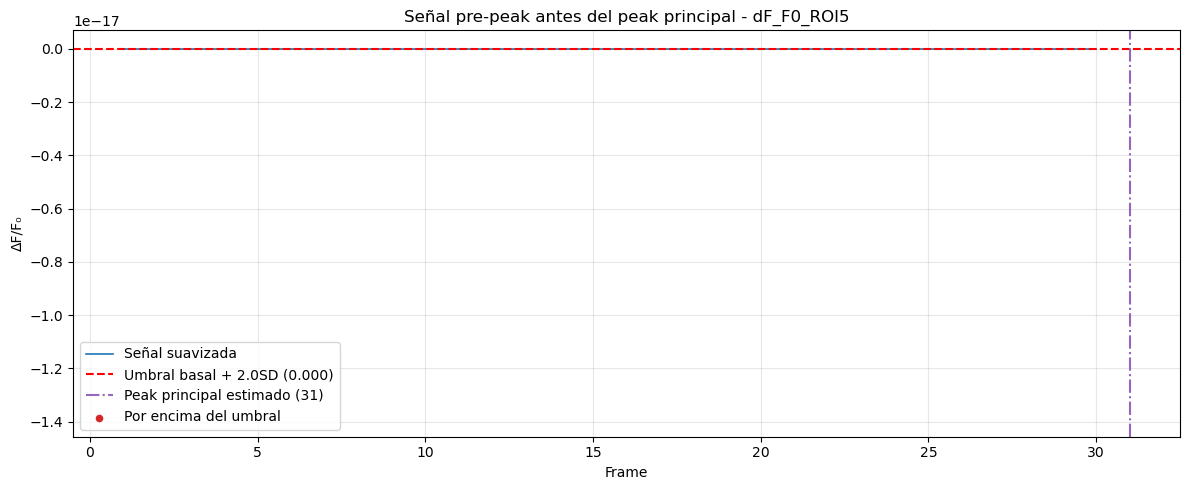

Resumen de la ROI seleccionada:
Empty DataFrame
Columns: []
Index: []


In [ ]:
# Archivo entregado en otro formato
archivo_nuevo = "14DIV_GCamp-NLS-jRGECO1aASX51_w1Channel-B.ods"
ruta_archivo = Path(archivo_nuevo)

# Ajuste de detección de columnas para el formato nuevo
# Este archivo puede tener columnas Unnamed si proviene de .ods.
def detectar_columnas_mean(df):
    mean_cols = []
    for col in df.columns:
        col_str = str(col).strip().lower()
        if "mean" in col_str:
            mean_cols.append(col)
        elif col_str.startswith("roi") and col_str[3:].isdigit():
            mean_cols.append(col)

    if len(mean_cols) == 0:
        # Si no hay nombres ROI/Mean, asumimos que la primera columna es Frame
        # y el resto son columnas de ROI, renombrándolas a ROI1, ROI2, ...
        if len(df.columns) > 1:
            roi_cols = list(df.columns[1:])
            rename_map = {old: f"ROI{i+1}" for i, old in enumerate(roi_cols)}
            df.rename(columns=rename_map, inplace=True)
            mean_cols = list(rename_map.values())

    if len(mean_cols) == 0:
        raise ValueError(
            "No se encontraron columnas con 'Mean' ni encabezados 'ROI'. "
            "Revisa el formato del archivo."
        )
    return mean_cols

# Cargar el archivo .ods y convertir los valores de ROI a numérico
raw_df = cargar_archivo(ruta_archivo)
if "Frame" not in raw_df.columns:
    raw_df = raw_df.rename(columns={raw_df.columns[0]: "Frame"})
raw_df["Frame"] = pd.to_numeric(raw_df["Frame"], errors="coerce")
if raw_df["Frame"].isna().any():
    raise ValueError("La columna de frames no se pudo convertir a numérico.")

roi_raw_cols = detectar_columnas_mean(raw_df)
analisis_nuevo = pd.DataFrame({"Frame": raw_df["Frame"]})

for col in roi_raw_cols:
    roi_name = str(col)
    serie = raw_df[col].astype(str).apply(parse_numeric_value)
    baseline = serie.iloc[:30].mean()
    if baseline == 0 or np.isnan(baseline):
        raise ValueError(f"No se puede calcular baseline para la columna {col}")
    analisis_nuevo[f"dF_F0_{roi_name}"] = (serie - baseline) / baseline

# Guardar análisis inicial con dF/F0
ruta_salida_nuevo = ruta_archivo.parent / ruta_archivo.stem
ruta_salida_nuevo.mkdir(exist_ok=True)
ruta_analisis_nuevo = ruta_salida_nuevo / f"{ruta_archivo.stem}_analisis_roi.xlsx"
analisis_nuevo.to_excel(ruta_analisis_nuevo, index=False)
print("Análisis dF/F0 generado en:", ruta_analisis_nuevo)

# Procesar pre-peak para todas las ROIs, excluyendo ROI8 si la grabación inicial está muy sesgada
exclude_rois = ["dF_F0_ROI8"]
df_resumen_pre_peak, df_eventos_pre_peak, df_candidatos_pre_peak, pre_peak_signales = procesar_pre_peak_todas(
    analisis_nuevo,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=1.8,
    min_frames=2,
    exclude_rois=exclude_rois,
)

print("ROIs excluidas:", exclude_rois)

# Guardar Excel adicional con el análisis pre-peak
carpeta_salida = ruta_archivo.parent / ruta_archivo.stem
carpeta_salida.mkdir(exist_ok=True)
ruta_pre_peak_excel = guardar_pre_peak_excel(
    ruta_archivo,
    carpeta_salida,
    df_resumen_pre_peak,
    df_eventos_pre_peak,
    df_candidatos_pre_peak,
    pre_peak_signales,
)

print("\nResumen general pre-peak:")
print(df_resumen_pre_peak)
print("\nExcel pre-peak generado en:", ruta_pre_peak_excel)

# Gráfico de solo pre-peak para una ROI seleccionada
umbral_factor_ajustado = 2.0
roi_elegida = "dF_F0_ROI5"
print(f"\nGraficando solo pre-peak para {roi_elegida} con umbral_factor={umbral_factor_ajustado}")
resultado_pre_peak = analizar_pre_peak(
    analisis_nuevo,
    roi=roi_elegida,
    n_baseline=30,
    ventana_suavizado=3,
    umbral_factor=umbral_factor_ajustado,
    min_frames=2,
    mostrar=True,
    solo_pre_peak=True,
)

print("Resumen de la ROI seleccionada:")
print(resultado_pre_peak["resumen_eventos"])

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

COLUMNAS_RESUMEN = [
    "Archivo",
    "Tipo señal",
    "Frames",
    "ROIs",
    "F0 usado",
    "Frame peak aprox.",
    "Eventos pre-peak",
    "Observación",
]

ruta_excel_resumen = "tabla_archivos_procesados.xlsx"


def cargar_archivos_procesados(ruta_excel=ruta_excel_resumen):
    """Carga la tabla resumen si ya existe; si no, devuelve una lista vacía."""
    ruta = Path(ruta_excel)
    if ruta.exists():
        try:
            df = pd.read_excel(ruta)
            if df.empty:
                return []
            return df[COLUMNAS_RESUMEN].to_dict(orient="records")
        except Exception as e:
            print(f"No se pudo cargar {ruta}: {e}")
    return []


def guardar_archivos_procesados(archivos_procesados, ruta_excel=ruta_excel_resumen):
    """Convierte la lista de registros en DataFrame y la guarda como Excel."""
    ruta = Path(ruta_excel)
    ruta.parent.mkdir(exist_ok=True, parents=True)
    df = pd.DataFrame(archivos_procesados, columns=COLUMNAS_RESUMEN)
    df.to_excel(ruta, index=False)
    return df


def registrar_archivo_desde_analisis(
    archivo,
    analisis,
    resultado_pre_peak=None,
    tipo_senal="Señal procesada",
    f0_usado="baseline de 30 frames",
    observacion="Procesado desde el notebook",
    ruta_excel=ruta_excel_resumen,
):
    """Registra un archivo usando los valores reales del análisis actual."""
    if analisis is None:
        raise ValueError("No hay un DataFrame de análisis disponible.")

    if resultado_pre_peak is None:
        frame_peak_aprox = None
        eventos_pre_peak = None
    else:
        frame_peak_aprox = resultado_pre_peak.get("frame_peak")
        eventos_pre_peak = len(resultado_pre_peak.get("resumen_eventos", []))

    n_rois = sum(1 for col in analisis.columns if col.startswith("dF_F0_"))
    fila = {
        "Archivo": Path(archivo).name if archivo is not None else "",
        "Tipo señal": tipo_senal,
        "Frames": int(len(analisis)),
        "ROIs": int(n_rois),
        "F0 usado": f0_usado,
        "Frame peak aprox.": int(frame_peak_aprox) if frame_peak_aprox is not None else None,
        "Eventos pre-peak": int(eventos_pre_peak) if eventos_pre_peak is not None else None,
        "Observación": observacion,
    }
    return fila


# Si ya existe un análisis actual en memoria, lo registra con valores reales.
if "archivo_nuevo" in globals() and "analisis_nuevo" in globals():
    registro_actual = registrar_archivo_desde_analisis(
        archivo=archivo_nuevo,
        analisis=analisis_nuevo,
        resultado_pre_peak=globals().get("resultado_pre_peak"),
        ruta_excel=ruta_excel_resumen,
    )
    archivos_procesados = cargar_archivos_procesados(ruta_excel_resumen)
    if not any(row.get("Archivo") == registro_actual["Archivo"] for row in archivos_procesados):
        archivos_procesados.append(registro_actual)
    tabla = guardar_archivos_procesados(archivos_procesados, ruta_excel=ruta_excel_resumen)
    print(tabla.to_string(index=False))
else:
    print("No hay un análisis activo en memoria. La tabla queda lista para cuando ejecutes un bloque con analisis_nuevo y resultado_pre_peak.")


No hay un análisis activo en memoria. La tabla queda lista para cuando ejecutes un bloque con analisis_nuevo y resultado_pre_peak.


In [ ]:
import pandas as pd
from pathlib import Path

COLUMNAS_DETALLE_EVENTOS = [
    "Archivo",
    "ROI",
    "Frame peak",
    "Eventos pre-peak",
    "Frame inicio evento",
    "Duración",
    "Pico del evento",
    "Amplitud",
]

COLUMNAS_RESUMEN_ARCHIVO = [
    "Archivo",
    "ROIs evaluadas",
    "ROIs con eventos",
    "Total eventos pre-peak",
    "Duración promedio",
    "Amplitud máxima",
]


def crear_tablas_eventos_pre_peak(
    archivo,
    resumen_df=None,
    eventos_df=None,
    ruta_detalle="tabla_eventos_pre_peak.xlsx",
    ruta_resumen="tabla_eventos_pre_peak_resumen.xlsx",
):
    """Crea una tabla detallada de eventos pre-peak y una tabla resumen por archivo."""
    ruta_detalle = Path(ruta_detalle)
    ruta_resumen = Path(ruta_resumen)
    ruta_detalle.parent.mkdir(exist_ok=True, parents=True)
    ruta_resumen.parent.mkdir(exist_ok=True, parents=True)

    if resumen_df is None or resumen_df.empty:
        resumen_df = pd.DataFrame(columns=["ROI", "Frame_peak", "N_eventos_robustos"])
    else:
        resumen_df = resumen_df.copy()

    if eventos_df is None or eventos_df.empty:
        detalle_df = pd.DataFrame(columns=COLUMNAS_DETALLE_EVENTOS)
        resumen_archivo_df = pd.DataFrame(columns=COLUMNAS_RESUMEN_ARCHIVO)
    else:
        eventos_df = eventos_df.copy()
        if "ROI" not in eventos_df.columns:
            raise ValueError("El DataFrame de eventos debe tener la columna 'ROI'.")

        # Contar eventos por ROI para la columna 'Eventos pre-peak'
        conteos = (
            eventos_df.groupby("ROI")
            .size()
            .rename("N_eventos_robustos")
            .reset_index()
        )
        resumen_join = resumen_df[["ROI", "Frame_peak"]].merge(conteos, on="ROI", how="left")
        resumen_join["N_eventos_robustos"] = resumen_join["N_eventos_robustos"].fillna(0).astype(int)

        detalle_df = eventos_df.merge(
            resumen_join[["ROI", "Frame_peak", "N_eventos_robustos"]],
            on="ROI",
            how="left",
        )
        detalle_df["Archivo"] = Path(archivo).name if archivo is not None else ""
        detalle_df["Frame peak"] = detalle_df["Frame_peak"]
        detalle_df["Eventos pre-peak"] = detalle_df["N_eventos_robustos"]
        detalle_df["Frame inicio evento"] = detalle_df["inicio"]
        detalle_df["Duración"] = detalle_df["duracion"]
        detalle_df["Pico del evento"] = detalle_df["pico_frame"]
        detalle_df["Amplitud"] = detalle_df["amplitud_vs_basal"]
        detalle_df = detalle_df[COLUMNAS_DETALLE_EVENTOS]

        # Resumen por archivo
        rois_evaluadas = len(resumen_df)
        rois_con_eventos = int(eventos_df["ROI"].nunique())
        total_eventos = int(len(eventos_df))
        duracion_promedio = float(eventos_df["duracion"].mean()) if not eventos_df.empty else 0.0
        amplitud_maxima = float(eventos_df["amplitud_vs_basal"].max()) if not eventos_df.empty else 0.0
        resumen_archivo_df = pd.DataFrame([
            {
                "Archivo": Path(archivo).name if archivo is not None else "",
                "ROIs evaluadas": rois_evaluadas,
                "ROIs con eventos": rois_con_eventos,
                "Total eventos pre-peak": total_eventos,
                "Duración promedio": duracion_promedio,
                "Amplitud máxima": amplitud_maxima,
            }
        ], columns=COLUMNAS_RESUMEN_ARCHIVO)

    detalle_df.to_excel(ruta_detalle, index=False)
    resumen_archivo_df.to_excel(ruta_resumen, index=False)

    print(f"Tabla detallada guardada en: {ruta_detalle}")
    print(f"Tabla resumen por archivo guardada en: {ruta_resumen}")
    return detalle_df, resumen_archivo_df


# Si ya existe un análisis de pre-peak en memoria, genera las tablas automáticamente.
if "archivo_nuevo" in globals() and "df_resumen_pre_peak" in globals() and "df_eventos_pre_peak" in globals():
    tabla_detalle, tabla_resumen = crear_tablas_eventos_pre_peak(
        archivo_nuevo,
        resumen_df=df_resumen_pre_peak,
        eventos_df=df_eventos_pre_peak,
        ruta_detalle="tabla_eventos_pre_peak.xlsx",
        ruta_resumen="tabla_eventos_pre_peak_resumen.xlsx",
    )
    display(tabla_detalle)
    display(tabla_resumen)
else:
    # Genera tablas vacías si aún no existe el análisis, para que el bloque quede listo para usar.
    tabla_detalle, tabla_resumen = crear_tablas_eventos_pre_peak(
        None,
        resumen_df=pd.DataFrame(columns=["ROI", "Frame_peak", "N_eventos_robustos"]),
        eventos_df=pd.DataFrame(columns=["ROI", "inicio", "fin", "duracion", "pico_frame", "pico_valor", "amplitud_vs_basal"]),
        ruta_detalle="tabla_eventos_pre_peak.xlsx",
        ruta_resumen="tabla_eventos_pre_peak_resumen.xlsx",
    )
    print("Listo para generar las tablas cuando ejecutes el análisis pre-peak de un archivo.")


Tabla detallada guardada en: tabla_eventos_pre_peak.xlsx
Tabla resumen por archivo guardada en: tabla_eventos_pre_peak_resumen.xlsx
Listo para generar las tablas cuando ejecutes el análisis pre-peak de un archivo.


In [7]:
import csv
from pathlib import Path

csv_path = Path('dataset_caracteristicas_IA.csv')
umap_path = Path('umap_coordenadas.csv')

if not csv_path.exists():
    raise FileNotFoundError('No se encontró dataset_caracteristicas_IA.csv. Asegúrate de que exista en la carpeta del notebook.')

with csv_path.open('r', encoding='utf-8', newline='') as f:
    rows = list(csv.DictReader(f))

print(f'Filas cargadas desde el dataset: {len(rows)}')
if rows:
    print('Columnas disponibles:')
    print(list(rows[0].keys()))
    print('\nVista previa de las primeras filas:')
    for row in rows[:5]:
        print(row)
else:
    print('El archivo CSV está vacío.')

if umap_path.exists():
    with umap_path.open('r', encoding='utf-8', newline='') as f:
        umap_rows = list(csv.DictReader(f))
    print('\nCoordenadas UMAP cargadas:')
    for row in umap_rows[:10]:
        print(row)
else:
    print('\nNo se encontró umap_coordenadas.csv; puedes ejecutarlo desde el script externo si lo necesitas.')

Filas cargadas desde el dataset: 103
Columnas disponibles:
['Archivo', 'ROI', 'Frame_peak', 'Media_basal', 'Std_basal', 'Umbral', 'N_candidatos', 'N_eventos_pre_peak', 'Duracion_promedio_eventos', 'Duracion_maxima_eventos', 'Amplitud_promedio_eventos', 'Amplitud_maxima_eventos', 'Frame_primer_evento', 'Frame_ultimo_evento', 'Distancia_primer_evento_al_peak', 'Clase_futura']

Vista previa de las primeras filas:
{'Archivo': '14DIV_GCaMP6-NLS-NMDA_control 4_Channel', 'ROI': 'dF_F0_ROI1', 'Frame_peak': '469', 'Media_basal': '-3.342444511944686e-06', 'Std_basal': '0.0001569957100086137', 'Umbral': '0.00027924983350356', 'N_candidatos': '212', 'N_eventos_pre_peak': '16', 'Duracion_promedio_eventos': '13', 'Duracion_maxima_eventos': '51', 'Amplitud_promedio_eventos': '0.002532873727097655', 'Amplitud_maxima_eventos': '0.02715081454628765', 'Frame_primer_evento': '80', 'Frame_ultimo_evento': '468', 'Distancia_primer_evento_al_peak': '389', 'Clase_futura': ''}
{'Archivo': '14DIV_GCaMP6-NLS-NMDA

In [8]:
import csv
from pathlib import Path

base_dir = Path('.')
dataset_path = base_dir / 'dataset_caracteristicas_IA.csv'
umap_path = base_dir / 'umap_coordenadas.csv'
plot_path = base_dir / 'umap_plot.svg'


def parse_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

with dataset_path.open('r', encoding='utf-8', newline='') as f:
    dataset_rows = list(csv.DictReader(f))

with umap_path.open('r', encoding='utf-8', newline='') as f:
    umap_rows = list(csv.DictReader(f))

coord_map = {}
for row in umap_rows:
    key = (row.get('Archivo', '').strip(), row.get('ROI', '').strip())
    x = parse_float(row.get('UMAP1'))
    y = parse_float(row.get('UMAP2'))
    if key and x is not None and y is not None:
        coord_map[key] = (x, y)

points = []
for row in dataset_rows:
    key = (row.get('Archivo', '').strip(), row.get('ROI', '').strip())
    coords = coord_map.get(key)
    if coords is None:
        continue
    label = (row.get('Clase_futura', '') or 'Sin_clase').strip() or 'Sin_clase'
    points.append((coords[0], coords[1], label))

if not points:
    raise RuntimeError('No se pudieron emparejar puntos UMAP con el dataset.')

xs = [p[0] for p in points]
ys = [p[1] for p in points]

xmin = min(xs)
xmax = max(xs)
ymin = min(ys)
ymax = max(ys)
if xmin == xmax:
    xmin -= 1
    xmax += 1
if ymin == ymax:
    ymin -= 1
    ymax += 1

width = 900
height = 600
margin = 40

labels = sorted({label for _, _, label in points})
color_map = {label: f'hsl({i * 360 / max(1, len(labels))}, 70%, 50%)' for i, label in enumerate(labels)}


def scale_value(v, lo, hi, size):
    if hi == lo:
        return size / 2
    return margin + (v - lo) * (size - 2 * margin) / (hi - lo)

parts = []
parts.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">')
parts.append('<rect width="100%" height="100%" fill="white" />')
parts.append('<g>')
for x, y, label in points:
    cx = scale_value(x, xmin, xmax, width)
    cy = height - scale_value(y, ymin, ymax, height)
    parts.append(f'<circle cx="{cx:.2f}" cy="{cy:.2f}" r="3" fill="{color_map[label]}" />')
parts.append('</g>')
parts.append('<g font-family="Arial" font-size="12" fill="#333">')
parts.append(f'<text x="{margin}" y="{margin - 10}">UMAP plot ({len(points)} puntos)</text>')
parts.append(f'<text x="{margin}" y="{height - 12}">UMAP1</text>')
parts.append(f'<text x="{width - 80}" y="{height - 12}">UMAP2</text>')
parts.append('</g>')
parts.append('</svg>')

plot_path.write_text('\n'.join(parts), encoding='utf-8')
print(f'Gráfico guardado en {plot_path}')
print(f'Puntos incluidos: {len(points)}')
print(f'Clases detectadas: {labels}')

Gráfico guardado en umap_plot.svg
Puntos incluidos: 103
Clases detectadas: ['Sin_clase']


In [12]:
import csv
import math
from pathlib import Path
from collections import defaultdict

base_dir = Path('.')
dataset_path = base_dir / 'dataset_caracteristicas_IA.csv'
umap_path = base_dir / 'umap_coordenadas.csv'
out_dir = base_dir / 'umap_sin_frame_peak'
out_dir.mkdir(exist_ok=True)


def parse_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def parse_int(value):
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return None


def mean(values):
    return sum(values) / len(values) if values else None


def variance(values):
    if len(values) < 2:
        return 0.0
    mu = mean(values)
    return sum((v - mu) ** 2 for v in values) / len(values)


with dataset_path.open('r', encoding='utf-8', newline='') as f:
    dataset_rows = list(csv.DictReader(f))

with umap_path.open('r', encoding='utf-8', newline='') as f:
    umap_rows = list(csv.DictReader(f))

coord_map = {}
for row in umap_rows:
    key = (row.get('Archivo', '').strip(), row.get('ROI', '').strip())
    x = parse_float(row.get('UMAP1'))
    y = parse_float(row.get('UMAP2'))
    if key and x is not None and y is not None:
        coord_map[key] = (x, y)

rows = []
for row in dataset_rows:
    key = (row.get('Archivo', '').strip(), row.get('ROI', '').strip())
    coords = coord_map.get(key)
    if coords is None:
        continue
    rows.append({
        'Archivo': row.get('Archivo', '').strip(),
        'ROI': row.get('ROI', '').strip(),
        'UMAP1': coords[0],
        'UMAP2': coords[1],
        'Media_basal': parse_float(row.get('Media_basal')),
        'Std_basal': parse_float(row.get('Std_basal')),
        'Umbral': parse_float(row.get('Umbral')),
        'N_candidatos': parse_int(row.get('N_candidatos')),
        'N_eventos_pre_peak': parse_int(row.get('N_eventos_pre_peak')),
        'Duracion_promedio_eventos': parse_float(row.get('Duracion_promedio_eventos')),
        'Duracion_maxima_eventos': parse_float(row.get('Duracion_maxima_eventos')),
        'Amplitud_promedio_eventos': parse_float(row.get('Amplitud_promedio_eventos')),
        'Amplitud_maxima_eventos': parse_float(row.get('Amplitud_maxima_eventos')),
        'Distancia_primer_evento_al_peak': parse_float(row.get('Distancia_primer_evento_al_peak')),
    })

if not rows:
    raise RuntimeError('No se pudieron emparejar puntos UMAP con el dataset.')

feature_sets = {
    'sin_frame_peak_y_distancia': [
        'Media_basal',
        'Std_basal',
        'Umbral',
        'N_candidatos',
        'N_eventos_pre_peak',
        'Duracion_promedio_eventos',
        'Duracion_maxima_eventos',
        'Amplitud_promedio_eventos',
        'Amplitud_maxima_eventos',
    ],
    'sin_frame_peak_y_distancia_mas_reducido': [
        'Media_basal',
        'Std_basal',
        'Umbral',
        'N_eventos_pre_peak',
        'Duracion_promedio_eventos',
        'Amplitud_promedio_eventos',
        'Amplitud_maxima_eventos',
    ],
}

for name, features in feature_sets.items():
    feature_rows = []
    for r in rows:
        values = []
        for feature in features:
            val = r.get(feature)
            if val is None:
                values = []
                break
            values.append(val)
        if not values:
            continue
        feature_rows.append((r['UMAP1'], r['UMAP2'], r['Archivo'], values))

    if not feature_rows:
        raise RuntimeError(f'No hay filas válidas para {name}')

    # Escalado simple por z-score
    feature_matrix = [vals for _, _, _, vals in feature_rows]
    n_features = len(features)
    means = [mean([row[i] for row in feature_matrix]) for i in range(n_features)]
    stds = []
    for i in range(n_features):
        col = [row[i] for row in feature_matrix]
        mu = means[i]
        if mu is None:
            stds.append(1.0)
        else:
            var = sum((v - mu) ** 2 for v in col) / max(1, len(col))
            stds.append(math.sqrt(var) if var > 0 else 1.0)
    scaled = []
    for vals in feature_matrix:
        scaled.append([(vals[i] - means[i]) / stds[i] if stds[i] != 0 else 0.0 for i in range(n_features)])

    # Distancia euclídea simple para un resumen rápido
    from itertools import combinations
    dists = []
    for a, b in combinations(range(len(feature_rows)), 2):
        ra = scaled[a]
        rb = scaled[b]
        dist = math.sqrt(sum((x - y) ** 2 for x, y in zip(ra, rb)))
        dists.append(dist)
    print(f'{name}: {len(feature_rows)} puntos, distancia media = {mean(dists):.3f} si hay al menos 2 puntos')

    # Guardar una tabla simple de resumen
    summary_path = out_dir / f'{name}_summary.csv'
    with summary_path.open('w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Archivo', 'ROI', 'UMAP1', 'UMAP2'] + features)
        for umap1, umap2, archivo, vals in feature_rows:
            writer.writerow([archivo, '', umap1, umap2] + vals)
    print(f'Guardado resumen: {summary_path}')

print('Listo para revisar si la separación persiste sin Frame_peak y Distancia_primer_evento_al_peak.')

sin_frame_peak_y_distancia: 97 puntos, distancia media = 3.307 si hay al menos 2 puntos
Guardado resumen: umap_sin_frame_peak\sin_frame_peak_y_distancia_summary.csv
sin_frame_peak_y_distancia_mas_reducido: 97 puntos, distancia media = 2.986 si hay al menos 2 puntos
Guardado resumen: umap_sin_frame_peak\sin_frame_peak_y_distancia_mas_reducido_summary.csv
Listo para revisar si la separación persiste sin Frame_peak y Distancia_primer_evento_al_peak.


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from sklearn.cluster import KMeans
except Exception:
    KMeans = None

base_dir = Path('.')
input_path = base_dir / 'dataset_caracteristicas_IA.csv'
output_path = base_dir / 'dataset_caracteristicas_IA_limpio.xlsx'
output_csv = base_dir / 'dataset_caracteristicas_IA_limpio.csv'
report_path = base_dir / 'dataset_caracteristicas_IA_limpio_reporte.csv'

if not input_path.exists():
    raise FileNotFoundError(f'No se encontró el dataset base: {input_path}')

# Cargar y normalizar
raw_df = pd.read_csv(input_path)
raw_df = raw_df.copy()
for col in ['Archivo', 'ROI']:
    raw_df[col] = raw_df[col].astype(str).str.strip()

feature_cols = [
    'Media_basal',
    'Std_basal',
    'Umbral',
    'N_eventos_pre_peak',
    'Duracion_promedio_eventos',
    'Amplitud_promedio_eventos',
    'Amplitud_maxima_eventos',
]

for col in feature_cols:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

# 1) Quitar ROIs con nombres no válidos
initial_rows = len(raw_df)
valid_roi_mask = ~raw_df['ROI'].str.startswith('Unnamed', na=False) & raw_df['ROI'].notna() & (raw_df['ROI'].str.strip() != '')
raw_df = raw_df.loc[valid_roi_mask].copy()
removed_unnamed = initial_rows - len(raw_df)

# 2) Quitar ROIs con valores todos en cero o sin información útil
zero_mask = raw_df[feature_cols].fillna(0).eq(0).all(axis=1)
raw_df = raw_df.loc[~zero_mask].copy()
removed_zero = initial_rows - removed_unnamed - len(raw_df)

# 3) Quitar outliers de amplitud exagerada (regla IQR)
amp = raw_df['Amplitud_maxima_eventos']
q1 = amp.quantile(0.25)
q3 = amp.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr
outlier_mask = amp > upper_fence
raw_df = raw_df.loc[~outlier_mask].copy()
removed_outliers = initial_rows - removed_unnamed - removed_zero - len(raw_df)

# 4) Quitar archivos con muy poca información útil después de la limpieza
file_counts = raw_df.groupby('Archivo').size()
valid_files = file_counts[file_counts >= 3].index
raw_df = raw_df.loc[raw_df['Archivo'].isin(valid_files)].copy()
removed_files = initial_rows - removed_unnamed - removed_zero - removed_outliers - len(raw_df)

# 5) Consolidar tabla final
final_df = raw_df[['Archivo', 'ROI'] + feature_cols].copy()
final_df = final_df.rename(columns={
    'N_eventos_pre_peak': 'N_eventos_pre_peak',
    'Duracion_promedio_eventos': 'Duracion_promedio_eventos',
    'Amplitud_promedio_eventos': 'Amplitud_promedio_eventos',
    'Amplitud_maxima_eventos': 'Amplitud_maxima_eventos',
})

# 6) Crear columna Cluster con agrupación simple y reproducible
if KMeans is not None and len(final_df) >= 6:
    X = final_df[feature_cols].fillna(0)
    X = (X - X.mean()) / X.std().replace(0, 1)
    n_clusters = min(3, max(2, len(final_df['Archivo'].unique())))
    clusters = KMeans(n_clusters=n_clusters, random_state=42, n_init=20).fit_predict(X)
    final_df['Cluster'] = clusters.astype(int)
else:
    def fallback_cluster(archivo):
        name = str(archivo).lower()
        if 'control' in name:
            return 0
        if 'asx' in name:
            return 1
        if 'ifen' in name:
            return 2
        return 3
    final_df['Cluster'] = final_df['Archivo'].apply(fallback_cluster)

# Ordenar y exportar
final_df = final_df.sort_values(['Archivo', 'ROI']).reset_index(drop=True)
final_df.to_excel(output_path, index=False)
final_df.to_csv(output_csv, index=False)

report = pd.DataFrame({
    'motivo': ['ROIs no válidas', 'ROIs con valores todos en cero', 'Outliers de amplitud', 'Archivos con poca información'],
    'filas_eliminadas': [removed_unnamed, removed_zero, removed_outliers, removed_files],
})
report.to_csv(report_path, index=False)

print(f'Filas iniciales: {initial_rows}')
print(f'Filas finales: {len(final_df)}')
print(report)
print(f'Archivo exportado: {output_path}')
print(f'CSV exportado: {output_csv}')
print(f'Reporte exportado: {report_path}')


Filas iniciales: 103
Filas finales: 83
                           motivo  filas_eliminadas
0                 ROIs no válidas                 0
1  ROIs con valores todos en cero                12
2            Outliers de amplitud                 8
3   Archivos con poca información                 0
Archivo exportado: dataset_caracteristicas_IA_limpio.xlsx
CSV exportado: dataset_caracteristicas_IA_limpio.csv
Reporte exportado: dataset_caracteristicas_IA_limpio_reporte.csv


In [14]:
import pandas as pd
from pathlib import Path

base_dir = Path('.')
clean_path = base_dir / 'dataset_caracteristicas_IA_limpio.xlsx'
qc_path = base_dir / 'control_calidad_ROIs.xlsx'
qc_csv = base_dir / 'control_calidad_ROIs.csv'

if not clean_path.exists():
    raise FileNotFoundError(f'No se encontró el dataset limpio: {clean_path}')

clean_df = pd.read_excel(clean_path)

# Construir tabla de control de calidad con criterios explícitos
qc_rows = []
for _, row in clean_df.iterrows():
    archivo = str(row['Archivo']).strip()
    roi = str(row['ROI']).strip()
    n_eventos = float(row.get('N_eventos_pre_peak', 0) or 0)
    amp_max = float(row.get('Amplitud_maxima_eventos', 0) or 0)
    amp_prom = float(row.get('Amplitud_promedio_eventos', 0) or 0)
    umbral = float(row.get('Umbral', 0) or 0)
    media_basal = float(row.get('Media_basal', 0) or 0)
    std_basal = float(row.get('Std_basal', 0) or 0)

    if pd.isna(media_basal) or pd.isna(std_basal) or pd.isna(umbral):
        tipo = 'ROI dudosa'
    elif abs(media_basal) < 1e-12 and abs(std_basal) < 1e-12 and umbral < 1e-12:
        tipo = 'ROI dudosa'
    elif n_eventos == 0:
        tipo = 'ROI sin eventos'
    elif amp_max > 0.02 or amp_prom > 0.01:
        tipo = 'ROI con alta actividad basal'
    else:
        tipo = 'ROI válida'

    qc_rows.append({
        'Archivo': archivo,
        'ROI': roi,
        'Media_basal': media_basal,
        'Std_basal': std_basal,
        'Umbral': umbral,
        'N_eventos_pre_peak': n_eventos,
        'Amplitud_promedio_eventos': amp_prom,
        'Amplitud_maxima_eventos': amp_max,
        'Tipo': tipo,
        'Observaciones': '',
    })

qc_df = pd.DataFrame(qc_rows)

# Anotar observaciones automáticas
for idx, row in qc_df.iterrows():
    obs = []
    if row['Tipo'] == 'ROI dudosa':
        obs.append('valores cercanos a cero o sin señal útil')
    elif row['Tipo'] == 'ROI sin eventos':
        obs.append('sin eventos pre-peak detectados')
    elif row['Tipo'] == 'ROI con alta actividad basal':
        obs.append('actividad basal alta o amplitud elevada')
    else:
        obs.append('señal razonable y eventos detectables')
    if row['Amplitud_maxima_eventos'] > 0.02:
        obs.append('amplitud máxima elevada')
    qc_df.at[idx, 'Observaciones'] = '; '.join(obs)

qc_df.to_excel(qc_path, index=False)
qc_df.to_csv(qc_csv, index=False)

print(qc_df['Tipo'].value_counts().to_string())
print(f'Archivo exportado: {qc_path}')
print(f'CSV exportado: {qc_csv}')


Tipo
ROI con alta actividad basal    42
ROI válida                      22
ROI sin eventos                 13
ROI dudosa                       6
Archivo exportado: control_calidad_ROIs.xlsx
CSV exportado: control_calidad_ROIs.csv


                                   Archivo          ROI  Media_basal  \
0  14DIV_GCaMP6-NLS-NMDA_control 4_Channel   dF_F0_ROI1    -0.000003   
1  14DIV_GCaMP6-NLS-NMDA_control 4_Channel  dF_F0_ROI10    -0.000008   
2  14DIV_GCaMP6-NLS-NMDA_control 4_Channel  dF_F0_ROI11    -0.000003   
3  14DIV_GCaMP6-NLS-NMDA_control 4_Channel  dF_F0_ROI12    -0.000005   
4  14DIV_GCaMP6-NLS-NMDA_control 4_Channel   dF_F0_ROI2    -0.000001   

   Std_basal    Umbral  N_eventos_pre_peak  Duracion_promedio_eventos  \
0   0.000157  0.000279                  16                  13.000000   
1   0.000673  0.001203                   3                   8.000000   
2   0.000214  0.000382                   7                  10.428571   
3   0.000248  0.000442                  14                  16.285714   
4   0.000333  0.000599                   4                   3.500000   

   Amplitud_promedio_eventos  Amplitud_maxima_eventos  Cluster  
0                   0.002533                 0.027151        0 

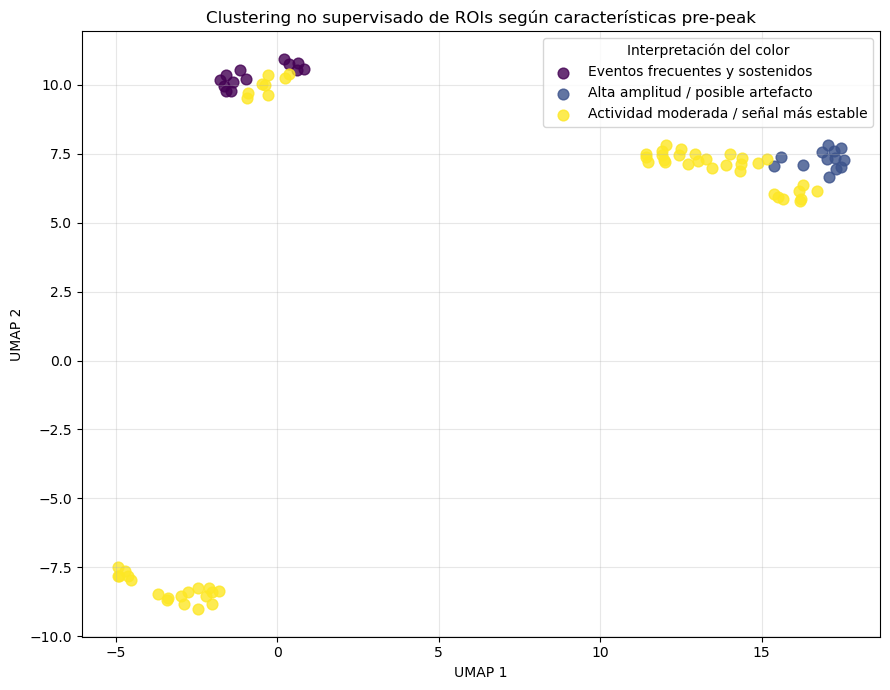


Resumen por cluster:
   Cluster  n_rois  N_eventos_pre_peak  Duracion_promedio_eventos  \
0        0      13            6.000000                  15.497680   
1        1      13            1.153846                   4.346154   
2        2      57            1.140351                   2.506433   

   Amplitud_promedio_eventos  Amplitud_maxima_eventos  \
0                   0.005073                 0.016250   
1                   0.536189                 0.547556   
2                   0.046234                 0.057685   

                                      Interpretacion  
0                    eventos frecuentes y sostenidos  
1  alta amplitud / posible señal extrema o artefacto  
2             actividad moderada / señal más estable  

Archivo guardado: dataset_caracteristicas_IA_con_clusters.xlsx
Resumen guardado: resumen_clusters.xlsx


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    import umap
except Exception as e:
    umap = None
    print(f'UMAP no disponible: {e}')

# =========================
# 1. CARGAR DATASET LIMPIO
# =========================
archivo = 'dataset_caracteristicas_IA_limpio.xlsx'
df = pd.read_excel(archivo)

print(df.head())
print(df.columns)
print('Número de ROIs:', len(df))

# =========================
# 2. SELECCIONAR VARIABLES
# =========================
features = [
    'Media_basal',
    'Std_basal',
    'Umbral',
    'N_eventos_pre_peak',
    'Duracion_promedio_eventos',
    'Amplitud_promedio_eventos',
    'Amplitud_maxima_eventos',
]

# Reemplazar infinitos y NaN

df_ml = df.copy()
df_ml[features] = df_ml[features].replace([np.inf, -np.inf], np.nan)
df_ml[features] = df_ml[features].fillna(0)

X = df_ml[features]

# =========================
# 3. ESCALAR VARIABLES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_ml['PCA1'] = X_pca[:, 0]
df_ml['PCA2'] = X_pca[:, 1]

print('Varianza explicada PCA:')
print(pca.explained_variance_ratio_)

# =========================
# 5. UMAP
# =========================
if umap is not None:
    reducer = umap.UMAP(
        n_neighbors=10,
        min_dist=0.2,
        n_components=2,
        random_state=42,
    )
    X_umap = reducer.fit_transform(X_scaled)
    df_ml['UMAP1'] = X_umap[:, 0]
    df_ml['UMAP2'] = X_umap[:, 1]
else:
    df_ml['UMAP1'] = X_pca[:, 0]
    df_ml['UMAP2'] = X_pca[:, 1]

# =========================
# 6. PROBAR K-MEANS CON VARIOS K
# =========================
resultados_k = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    resultados_k.append({'k': k, 'silhouette': score})

df_k = pd.DataFrame(resultados_k)
print(df_k)

# =========================
# 7. ELEGIR K
# =========================
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

# =========================
# 8. GRAFICAR UMAP CON CLUSTERS
# =========================
cluster_color_map = {
    0: ('#440154', 'Eventos frecuentes y sostenidos'),
    1: ('#3b528b', 'Alta amplitud / posible artefacto'),
    2: ('#fde725', 'Actividad moderada / señal más estable'),
}

plt.figure(figsize=(9, 7))
for cluster_id, (color, label) in cluster_color_map.items():
    subset = df_ml[df_ml['Cluster'] == cluster_id]
    if subset.empty:
        continue
    plt.scatter(
        subset['UMAP1'],
        subset['UMAP2'],
        c=[color],
        s=60,
        alpha=0.8,
        label=label,
    )

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('Clustering no supervisado de ROIs según características pre-peak')
plt.grid(True, alpha=0.3)
plt.legend(title='Interpretación del color')
plt.tight_layout()
plt.show()

# =========================
# 9. RESUMEN DE CADA CLUSTER
# =========================
cluster_summary = df_ml.groupby('Cluster')[features].mean().round(6).reset_index()
cluster_summary['n_rois'] = df_ml.groupby('Cluster').size().values
cluster_summary = cluster_summary.sort_values('Cluster').reset_index(drop=True)

cluster_summary['event_score'] = cluster_summary['N_eventos_pre_peak'] + cluster_summary['Duracion_promedio_eventos']
cluster_summary['amplitude_score'] = cluster_summary['Amplitud_promedio_eventos'] + cluster_summary['Amplitud_maxima_eventos']

cluster_summary['Interpretacion'] = np.where(
    cluster_summary['amplitude_score'] > cluster_summary['amplitude_score'].median() * 1.5,
    'alta amplitud / posible señal extrema o artefacto',
    np.where(
        cluster_summary['event_score'] > cluster_summary['event_score'].median() * 1.2,
        'eventos frecuentes y sostenidos',
        'actividad moderada / señal más estable',
    ),
)

print('\nResumen por cluster:')
print(cluster_summary[['Cluster', 'n_rois', 'N_eventos_pre_peak', 'Duracion_promedio_eventos', 'Amplitud_promedio_eventos', 'Amplitud_maxima_eventos', 'Interpretacion']])

cluster_summary.to_excel('resumen_clusters.xlsx', index=False)
cluster_summary.to_csv('resumen_clusters.csv', index=False)

# =========================
# 10. GUARDAR DATASET CON CLUSTERS
# =========================
output_path = Path('dataset_caracteristicas_IA_con_clusters.xlsx')
df_ml.to_excel(output_path, index=False)
print('\nArchivo guardado:', output_path)
print('Resumen guardado: resumen_clusters.xlsx')


   Cluster  N_ROIs  Media_eventos  Max_eventos  Duracion_promedio  \
0        0      13       6.000000           16          15.497680   
1        1      13       1.153846            2           4.346154   
2        2      57       1.140351            5           2.506433   

   Amplitud_promedio  Amplitud_maxima  Std_basal_promedio  Umbral_promedio  
0           0.005073         0.028618            0.000518         0.000932  
1           0.536189         0.933886            0.007935         0.014261  
2           0.046234         0.375930            0.001843         0.003621  


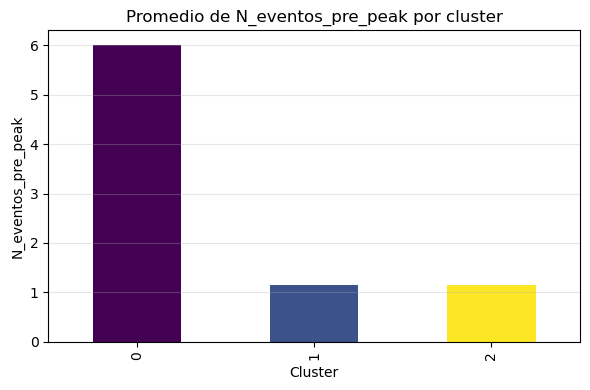

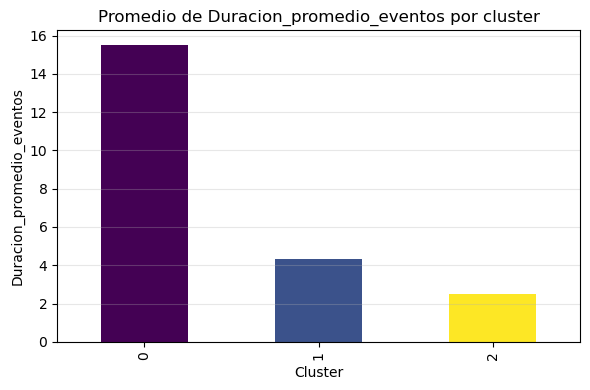

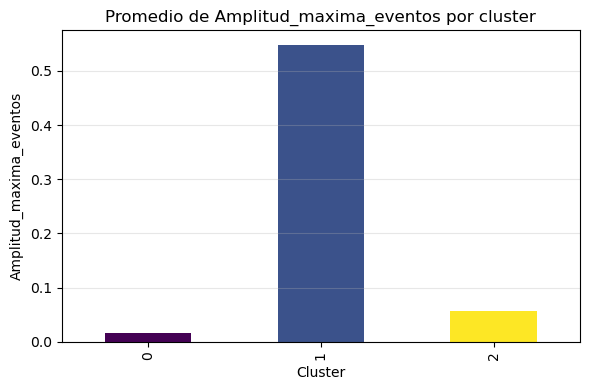

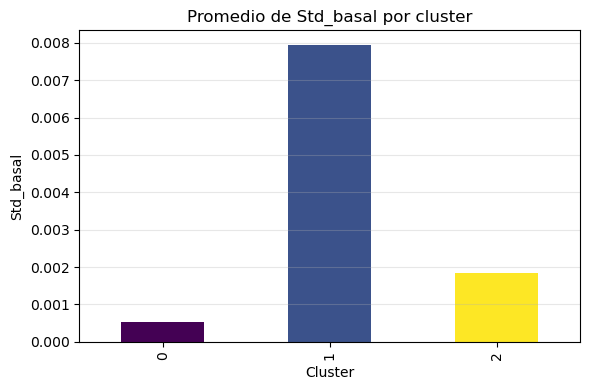

In [19]:
# Tabla resumen por cluster
resumen_simple = df_ml.groupby('Cluster').agg(
    N_ROIs=('Cluster', 'count'),
    Media_eventos=('N_eventos_pre_peak', 'mean'),
    Max_eventos=('N_eventos_pre_peak', 'max'),
    Duracion_promedio=('Duracion_promedio_eventos', 'mean'),
    Amplitud_promedio=('Amplitud_promedio_eventos', 'mean'),
    Amplitud_maxima=('Amplitud_maxima_eventos', 'max'),
    Std_basal_promedio=('Std_basal', 'mean'),
    Umbral_promedio=('Umbral', 'mean')
).reset_index()

resumen_simple.to_excel('resumen_simple_clusters.xlsx', index=False)
print(resumen_simple)

# Gráficos de barras por cluster
variables_graficar = [
    'N_eventos_pre_peak',
    'Duracion_promedio_eventos',
    'Amplitud_maxima_eventos',
    'Std_basal',
]

for var in variables_graficar:
    medias = df_ml.groupby('Cluster')[var].mean()

    plt.figure(figsize=(6, 4))
    medias.plot(kind='bar', color=['#440154', '#3b528b', '#fde725'])
    plt.xlabel('Cluster')
    plt.ylabel(var)
    plt.title(f'Promedio de {var} por cluster')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


   Cluster ROI_representativa Columna_representativa  frame_peak  \
0        0         dF_F0_ROI1             dF_F0_ROI1         150   
1        1         dF_F0_ROI2             dF_F0_ROI2         164   
2        2         dF_F0_ROI7             dF_F0_ROI7         150   

   score_representativa  
0          2.019321e+01  
1          1.020625e+00  
2         -8.879695e-07  


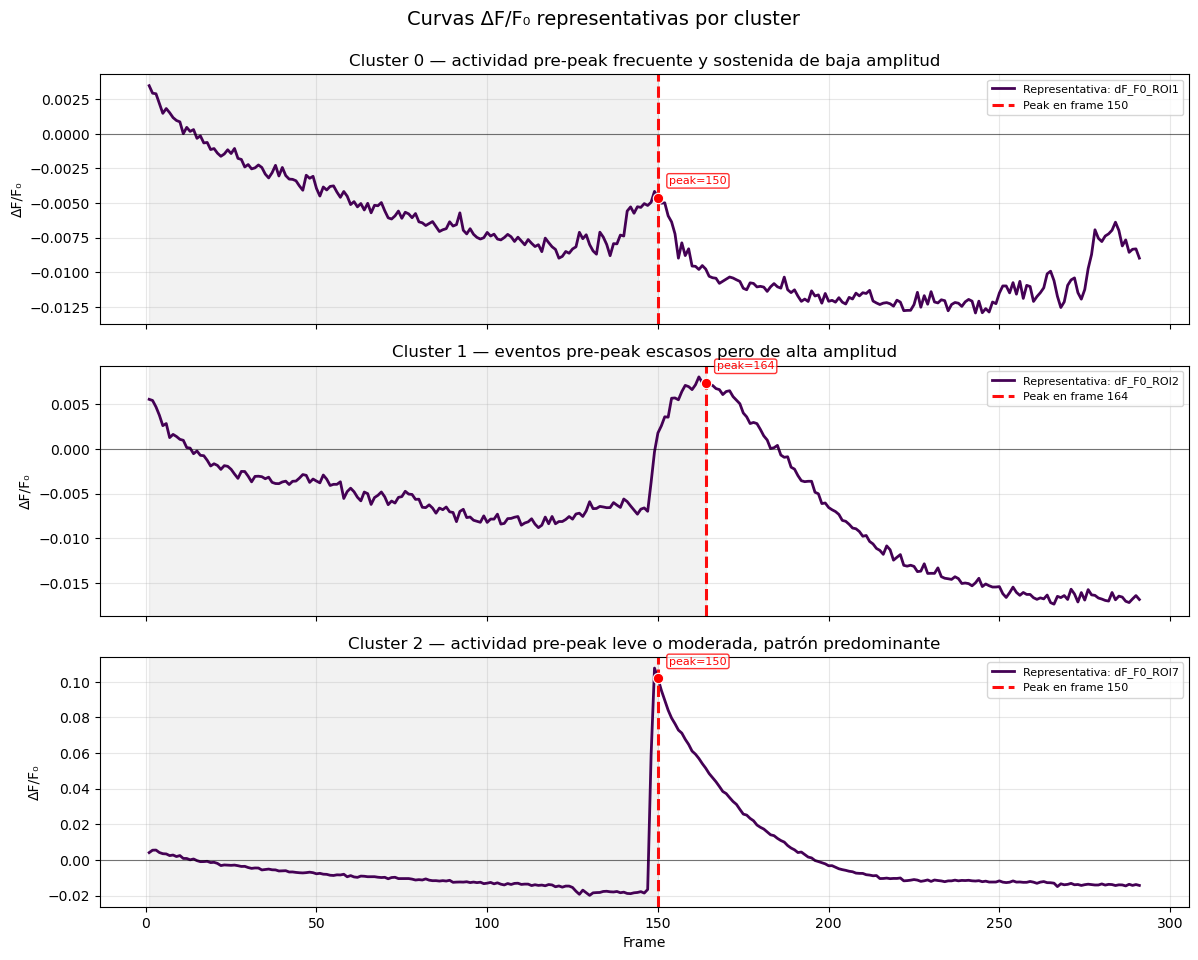

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Elegir curvas representativas por cluster
# =========================

if 'analisis_nuevo' not in globals():
    raise NameError('No existe la variable analisis_nuevo con las curvas ΔF/F₀.')

if 'X_scaled' not in globals():
    raise NameError('No existe X_scaled para medir la distancia al centro del cluster.')

if 'Cluster' not in df_ml.columns:
    raise ValueError('df_ml no tiene la columna Cluster.')

# Preparar la tabla de curvas
if 'normalizar_nombres_roi' in globals():
    analisis_plot = normalizar_nombres_roi(analisis_nuevo.copy())
else:
    analisis_plot = analisis_nuevo.copy()


def resolver_columna_roi(roi_name, df):
    if roi_name in df.columns:
        return roi_name

    if roi_name.startswith('dF_F0_ROI'):
        alternativo = roi_name.replace('dF_F0_ROI', 'dF_F0_Mean', 1)
        if alternativo in df.columns:
            return alternativo
    elif roi_name.startswith('dF_F0_Mean'):
        alternativo = roi_name.replace('dF_F0_Mean', 'dF_F0_ROI', 1)
        if alternativo in df.columns:
            return alternativo

    sufijo = ''.join(ch for ch in roi_name if ch.isdigit())
    for col in df.columns:
        if col.startswith('dF_F0_') and ''.join(ch for ch in col if ch.isdigit()) == sufijo:
            return col

    return None


def pendiente_absoluta(series):
    series = pd.to_numeric(series, errors='coerce').dropna()
    if len(series) < 2:
        return np.nan
    x = np.arange(len(series))
    return abs(np.polyfit(x, series, 1)[0])


def obtener_frame_peak(roi_name, cluster_id=None):
    col = resolver_columna_roi(roi_name, analisis_plot)
    if col is None:
        return None

    df_local = analisis_plot[['Frame', col]].copy()
    if cluster_id == 0:
        df_local = df_local[df_local['Frame'] >= 50].copy()

    if df_local.empty:
        return None

    if cluster_id == 0:
        series = pd.to_numeric(df_local[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
        if series.dropna().empty:
            return None

        sub = pd.DataFrame({'Frame': df_local['Frame'].to_numpy(), 'y': series.to_numpy()}).dropna().reset_index(drop=True)
        if sub.empty:
            return None

        # Evitar picos de borde al final: concentrar búsqueda en el tramo central útil.
        frame_cut = float(np.nanquantile(sub['Frame'].to_numpy(dtype=float), 0.90))
        sub_mid = sub[sub['Frame'] <= frame_cut].copy().reset_index(drop=True)
        if len(sub_mid) < 5:
            sub_mid = sub.copy()

        smoothed = sub_mid['y'].rolling(5, center=True, min_periods=1).mean().to_numpy()

        best_idx = None
        best_score = None
        for i in range(1, len(smoothed) - 1):
            if np.isnan(smoothed[i]):
                continue
            if smoothed[i] >= smoothed[i - 1] and smoothed[i] >= smoothed[i + 1]:
                left = max(0, i - 25)
                local_valley = np.nanmin(smoothed[left:i + 1])
                prominence = float(smoothed[i] - local_valley)
                # Prioriza picos con subida real desde un valle local.
                score = prominence + 0.05 * float(smoothed[i])
                if best_score is None or score > best_score:
                    best_score = score
                    best_idx = i

        if best_idx is None:
            best_idx = int(np.nanargmax(smoothed))

        return int(sub_mid['Frame'].iloc[best_idx])

    if cluster_id == 1:
        series = pd.to_numeric(df_local[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
        if series.dropna().empty:
            return None

        smoothed = series.rolling(7, center=True, min_periods=1).mean()
        baseline = smoothed.iloc[:30].dropna()
        if baseline.empty:
            baseline = smoothed.dropna()
        baseline_mean = float(np.nanmean(baseline))
        baseline_std = float(np.nanstd(baseline))
        threshold = baseline_mean + max(2.0 * baseline_std, 0.01 * (np.nanmax(smoothed) - baseline_mean + 1e-9))

        candidates = []
        for i in range(1, len(smoothed) - 1):
            if np.isnan(smoothed.iloc[i]):
                continue
            if smoothed.iloc[i] >= smoothed.iloc[i - 1] and smoothed.iloc[i] >= smoothed.iloc[i + 1]:
                if smoothed.iloc[i] >= threshold:
                    candidates.append(i)

        if not candidates:
            candidates = [int(np.nanargmax(smoothed.to_numpy()))]

        best_idx = None
        best_score = None
        for idx in candidates:
            value = float(smoothed.iloc[idx])
            prominence = value - baseline_mean
            left_window = smoothed.iloc[max(0, idx - 6):idx + 1].dropna()
            right_window = smoothed.iloc[idx:min(len(smoothed), idx + 7)].dropna()
            sustain = float(np.count_nonzero(left_window >= threshold)) + float(np.count_nonzero(right_window >= threshold))
            score = prominence + 0.08 * sustain
            if best_score is None or score > best_score:
                best_score = score
                best_idx = idx

        if best_idx is None:
            best_idx = int(np.nanargmax(smoothed.to_numpy()))

        return int(df_local['Frame'].iloc[best_idx])

    if 'analizar_pre_peak' in globals():
        resultado = analizar_pre_peak(
            df_local,
            roi=col,
            n_baseline=30,
            ventana_suavizado=3,
            umbral_factor=2.0,
            min_frames=2,
            mostrar=False,
            solo_pre_peak=False,
        )
        if resultado.get('frame_peak') is not None:
            return int(resultado['frame_peak'])

    if 'df_resumen_pre_peak' in globals():
        summary = globals()['df_resumen_pre_peak']
        if 'ROI' in summary.columns and 'Frame_peak' in summary.columns:
            match = summary[summary['ROI'] == roi_name]
            if not match.empty:
                return int(match['Frame_peak'].iloc[0])

    series = pd.to_numeric(df_local[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    if series.dropna().empty:
        return None

    peak_idx = int(np.nanargmax(series.to_numpy()))
    return int(df_local['Frame'].iloc[peak_idx])

# Mantener solo las ROIs de df_ml que sí existen en las curvas actuales
mask_plot = df_ml['ROI'].apply(lambda roi: resolver_columna_roi(roi, analisis_plot) is not None)
plot_df = df_ml.loc[mask_plot].copy()
plot_df['Cluster'] = plot_df['Cluster'].astype(int)

if plot_df.empty:
    raise ValueError('No hay ROIs de df_ml que puedan mapearse a las curvas disponibles en analisis_nuevo.')

clusters = sorted(plot_df['Cluster'].unique())

textos_cluster = {
    0: 'actividad pre-peak frecuente y sostenida de baja amplitud',
    1: 'eventos pre-peak escasos pero de alta amplitud',
    2: 'actividad pre-peak leve o moderada, patrón predominante',
}

representantes = []

for cluster_id in clusters:
    cluster_rows = plot_df[plot_df['Cluster'] == cluster_id].copy()
    if cluster_rows.empty:
        continue

    opciones = []
    for _, row in cluster_rows.iterrows():
        col = resolver_columna_roi(row['ROI'], analisis_plot)
        if col is None:
            continue
        serie = analisis_plot[col].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
        if serie.empty:
            continue
        slope = pendiente_absoluta(serie)

        if cluster_id == 0:
            score = (
                row['N_eventos_pre_peak'] * 1.1
                + row['Duracion_promedio_eventos'] * 0.2
                - row['Amplitud_maxima_eventos'] * 0.25
                - slope * 0.1
            )
        elif cluster_id == 1:
            score = (
                row['Amplitud_maxima_eventos'] * 1.2
                + row['N_eventos_pre_peak'] * 0.15
                - slope * 0.25
            )
        else:
            score = (
                -row['N_eventos_pre_peak'] * 0.8
                - row['Amplitud_maxima_eventos'] * 0.25
                - slope * 0.1
            )

        opciones.append({
            'ROI': row['ROI'],
            'Columna': col,
            'score': score,
            'amplitud': row['Amplitud_maxima_eventos'],
            'eventos': row['N_eventos_pre_peak'],
            'duracion': row['Duracion_promedio_eventos'],
            'slope': slope,
        })

    if not opciones:
        continue

    opciones_df = pd.DataFrame(opciones).sort_values('score', ascending=False)
    representativa = opciones_df.iloc[0]
    frame_peak = obtener_frame_peak(representativa['ROI'], cluster_id=int(cluster_id))

    representantes.append({
        'Cluster': int(cluster_id),
        'ROI_representativa': representativa['ROI'],
        'Columna_representativa': representativa['Columna'],
        'frame_peak': frame_peak,
        'score_representativa': float(representativa['score']),
    })

representantes_df = pd.DataFrame(representantes).sort_values('Cluster').reset_index(drop=True)
representantes_df.to_excel('representantes_clusters.xlsx', index=False)
print(representantes_df)

# Figura principal: una curva representativa limpia por cluster
fig, axes = plt.subplots(len(representantes_df), 1, figsize=(12, 3.2 * len(representantes_df)), sharex=True)
if len(representantes_df) == 1:
    axes = [axes]

for ax, row in zip(axes, representantes_df.itertuples(index=False)):
    ax.plot(
        analisis_plot['Frame'],
        analisis_plot[row.Columna_representativa],
        color='#440154',
        linewidth=2,
        label=f'Representativa: {row.ROI_representativa}'
    )

    if row.frame_peak is not None:
        ax.axvspan(analisis_plot['Frame'].min(), row.frame_peak, color='gray', alpha=0.10)
        ax.axvline(
            row.frame_peak,
            color='red',
            linestyle='--',
            linewidth=2.2,
            alpha=0.95,
            label=f'Peak en frame {row.frame_peak}'
        )

        peak_y_series = analisis_plot.loc[
            analisis_plot['Frame'] == row.frame_peak,
            row.Columna_representativa,
        ]
        if not peak_y_series.empty:
            peak_y = float(peak_y_series.iloc[0])
            ax.scatter(
                [row.frame_peak],
                [peak_y],
                color='red',
                s=56,
                zorder=6,
                edgecolors='white',
                linewidths=0.8,
            )
            ax.annotate(
                f'peak={row.frame_peak}',
                xy=(row.frame_peak, peak_y),
                xytext=(8, 10),
                textcoords='offset points',
                color='red',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.8),
            )

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    titulo = textos_cluster.get(int(row.Cluster), 'patrón de actividad')
    ax.set_title(f'Cluster {row.Cluster} — {titulo}')
    ax.set_ylabel('ΔF/F₀')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Frame')
fig.suptitle('Curvas ΔF/F₀ representativas por cluster', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig('curvas_representativas_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:
import numpy as np
import pandas as pd

roi = 'dF_F0_ROI2'
col = resolver_columna_roi(roi, analisis_plot)
series = pd.to_numeric(analisis_plot[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
smoothed = series.rolling(7, center=True, min_periods=1).mean()
frame = analisis_plot['Frame']

# Mostrar los valores más relevantes de la curva
print('Columna:', col)
print(pd.DataFrame({'Frame': frame, 'raw': series, 'smooth': smoothed}).head(80).to_string(index=False))
print('\nPicos candidatos por máximo local:')
for i in range(1, len(smoothed)-1):
    if (smoothed.iloc[i] >= smoothed.iloc[i-1]) and (smoothed.iloc[i] >= smoothed.iloc[i+1]):
        if smoothed.iloc[i] > np.nanmean(smoothed.iloc[:30]) + np.nanstd(smoothed.iloc[:30]):
            print(i, int(frame.iloc[i]), float(smoothed.iloc[i]))


Columna: dF_F0_ROI2
 Frame       raw    smooth
     1  0.005550  0.004860
     2  0.005424  0.004409
     3  0.004702  0.004148
     4  0.003764  0.003736
     5  0.002606  0.003176
     6  0.002841  0.002600
     7  0.001268  0.002082
     8  0.001626  0.001682
     9  0.001391  0.001332
    10  0.001076  0.000940
    11  0.000967  0.000683
    12  0.000156  0.000418
    13  0.000093  0.000117
    14 -0.000532 -0.000145
    15 -0.000227 -0.000464
    16 -0.000715 -0.000759
    17 -0.000756 -0.001009
    18 -0.001268 -0.001196
    19 -0.001907 -0.001491
    20 -0.001657 -0.001655
    21 -0.001844 -0.001825
    22 -0.002286 -0.001969
    23 -0.001868 -0.002097
    24 -0.001942 -0.002331
    25 -0.002277 -0.002426
    26 -0.002806 -0.002460
    27 -0.003289 -0.002629
    28 -0.002515 -0.002877
    29 -0.002523 -0.002990
    30 -0.003050 -0.003025
    31 -0.003679 -0.002999
    32 -0.003069 -0.003115
    33 -0.003050 -0.003206
    34 -0.003104 -0.003303
    35 -0.003331 -0.003330
    36 -

In [37]:
# Diagnóstico de peak para la ROI representativa del Cluster 0
if 'df_resumen_pre_peak' in globals():
    print(df_resumen_pre_peak[['ROI','Frame_peak']].head(10))

roi_test = 'dF_F0_ROI1'
if roi_test in analisis_plot.columns:
    print('\nROI test:', roi_test)
    print('Frame_peak desde resumen:', df_resumen_pre_peak[df_resumen_pre_peak['ROI'] == roi_test]['Frame_peak'].tolist() if 'df_resumen_pre_peak' in globals() else 'no disponible')
    resultado = analizar_pre_peak(analisis_plot, roi=roi_test, n_baseline=30, ventana_suavizado=3, umbral_factor=2.0, min_frames=2, mostrar=False)
    print('Frame_peak desde analizar_pre_peak:', resultado['frame_peak'])
    print('Umbral:', resultado['umbral'])
    print('Media basal:', resultado['media_basal'])
    print('Std basal:', resultado['std_basal'])
    print('Primeros 20 frames:')
    print(analisis_plot[["Frame", roi_test]].head(20))


          ROI  Frame_peak
0  dF_F0_ROI1          13
1  dF_F0_ROI2         163
2  dF_F0_ROI3           2
3  dF_F0_ROI4          22
4  dF_F0_ROI5         148
5  dF_F0_ROI6          47
6  dF_F0_ROI7         150

ROI test: dF_F0_ROI1
Frame_peak desde resumen: [13]
Frame_peak desde analizar_pre_peak: 13
Umbral: 0.003641212741711466
Media basal: 0.001633229488414034
Std basal: 0.001003991626648716
Primeros 20 frames:
    Frame  dF_F0_ROI1
0       1    0.003473
1       2    0.002933
2       3    0.002890
3       4    0.002193
4       5    0.001478
5       6    0.001824
6       7    0.001525
7       8    0.001171
8       9    0.000963
9      10    0.000864
10     11    0.000007
11     12    0.000466
12     13    0.000174
13     14    0.000306
14     15   -0.000324
15     16   -0.000145
16     17   -0.000657
17     18   -0.000622
18     19   -0.001135
19     20   -0.001062


In [23]:
print('Columnas de analisis_nuevo:')
print([c for c in analisis_nuevo.columns if c.startswith('dF_F0_')][:20])
print('\nColumnas de analisis_plot:')
print([c for c in analisis_plot.columns if c.startswith('dF_F0_')][:20])
print('\nROIs en df_ml:')
print(df_ml['ROI'].tolist()[:20])


Columnas de analisis_nuevo:
['dF_F0_ROI1', 'dF_F0_ROI2', 'dF_F0_ROI3', 'dF_F0_ROI4', 'dF_F0_ROI5', 'dF_F0_ROI6', 'dF_F0_ROI7', 'dF_F0_ROI8']

Columnas de analisis_plot:
['dF_F0_ROI1', 'dF_F0_ROI2', 'dF_F0_ROI3', 'dF_F0_ROI4', 'dF_F0_ROI5', 'dF_F0_ROI6', 'dF_F0_ROI7', 'dF_F0_ROI8']

ROIs en df_ml:
['dF_F0_ROI1', 'dF_F0_ROI10', 'dF_F0_ROI11', 'dF_F0_ROI12', 'dF_F0_ROI2', 'dF_F0_ROI3', 'dF_F0_ROI4', 'dF_F0_ROI5', 'dF_F0_ROI6', 'dF_F0_ROI7', 'dF_F0_ROI9', 'dF_F0_ROI1', 'dF_F0_ROI2', 'dF_F0_ROI3', 'dF_F0_ROI4', 'dF_F0_ROI5', 'dF_F0_ROI6', 'dF_F0_ROI7', 'dF_F0_ROI1', 'dF_F0_ROI10']


In [38]:
import numpy as np
import pandas as pd

roi = 'dF_F0_ROI1'
col = resolver_columna_roi(roi, analisis_plot)
series = pd.to_numeric(analisis_plot[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
frame = analisis_plot['Frame']

# Analizar solo desde frame 50 para cluster 0
mask = frame >= 50
sub = pd.DataFrame({'Frame': frame[mask].to_numpy(), 'y': series[mask].to_numpy()}).dropna().reset_index(drop=True)
sub['smooth'] = sub['y'].rolling(5, center=True, min_periods=1).mean()
arr = sub['smooth'].to_numpy()

candidatos = []
for i in range(1, len(arr)-1):
    if arr[i] >= arr[i-1] and arr[i] >= arr[i+1]:
        left = max(0, i-25)
        valley = np.nanmin(arr[left:i+1]) if i > left else arr[i]
        prominence = float(arr[i] - valley)
        candidatos.append((i, int(sub.loc[i, 'Frame']), float(arr[i]), float(valley), prominence))

candidatos = sorted(candidatos, key=lambda x: x[4], reverse=True)
print('Top candidatos por prominencia:')
for row in candidatos[:8]:
    print(row)


Top candidatos por prominencia:
(233, 283, -0.006977000419236719, -0.011579076098861028, 0.004602075679624309)
(230, 280, -0.007363432076304077, -0.011579076098861028, 0.00421564402255695)
(100, 150, -0.004736800355075595, -0.008132109523153939, 0.0033953091680783438)
(214, 264, -0.010634687359395741, -0.012674251193927361, 0.0020395638345316203)
(204, 254, -0.011078769824976865, -0.012674251193927361, 0.0015954813689504962)
(202, 252, -0.011129095365742163, -0.012674251193927361, 0.0015451558281851987)
(206, 256, -0.011150405235555837, -0.012674251193927361, 0.0015238459583715239)
(222, 272, -0.011049944420720005, -0.01255200484254097, 0.0015020604218209648)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===============================
# 1) Cargar dataset de características
# ===============================
dataset_path = Path('dataset_caracteristicas_IA_con_clusters.xlsx')
if not dataset_path.exists():
    raise FileNotFoundError(f'No se encontró {dataset_path}.')

df = pd.read_excel(dataset_path)
print('Filas dataset:', len(df))
print('Columnas disponibles:', list(df.columns))

# ===============================
# 2) Definir columna de peak
# ===============================
peak_candidates = [
    'Peak_dF_F0',
    'peak_value',
    'Peak',
    'Max_peak',
    'amplitud_peak',
]

col_peak = next((c for c in peak_candidates if c in df.columns), None)

# Si no existe columna de peak, construirla leyendo archivos *_analisis_roi.xlsx
if col_peak is None:
    print('No se encontró columna de peak. Se calculará Peak_dF_F0 desde archivos de análisis.')
    search_roots = [Path('.')]
    if 'archivo_nuevo' in globals():
        try:
            search_roots.append(Path(archivo_nuevo).parent)
        except Exception:
            pass

    def resolver_columna_roi_en_analisis(roi_name, analisis_df):
        if roi_name in analisis_df.columns:
            return roi_name

        if isinstance(roi_name, str):
            if roi_name.startswith('dF_F0_ROI'):
                alt = roi_name.replace('dF_F0_ROI', 'dF_F0_Mean', 1)
                if alt in analisis_df.columns:
                    return alt
            if roi_name.startswith('dF_F0_Mean'):
                alt = roi_name.replace('dF_F0_Mean', 'dF_F0_ROI', 1)
                if alt in analisis_df.columns:
                    return alt

            sufijo = ''.join(ch for ch in roi_name if ch.isdigit())
            if sufijo:
                for c in analisis_df.columns:
                    if not str(c).startswith('dF_F0_'):
                        continue
                    if ''.join(ch for ch in str(c) if ch.isdigit()) == sufijo:
                        return c
        return None

    peak_values = []
    not_found = 0
    for _, row in df.iterrows():
        archivo_base = str(row.get('Archivo', '')).strip()
        roi = str(row.get('ROI', '')).strip()

        posibles = []
        for root in search_roots:
            posibles.extend(list(root.rglob(f"{Path(archivo_base).stem}*_analisis_roi*.xlsx")))

        if len(posibles) == 0:
            peak_values.append(np.nan)
            not_found += 1
            continue

        ruta_analisis = posibles[0]
        analisis = pd.read_excel(ruta_analisis)
        roi_col = resolver_columna_roi_en_analisis(roi, analisis)

        if roi_col is None:
            peak_values.append(np.nan)
            continue

        senal = pd.to_numeric(analisis[roi_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(senal) == 0:
            peak_values.append(np.nan)
        else:
            peak_values.append(float(senal.max()))

    df['Peak_dF_F0'] = peak_values
    col_peak = 'Peak_dF_F0'
    print(f'Se calculó {col_peak}. Archivos sin match: {not_found}')

    out_with_peak = Path('dataset_caracteristicas_IA_con_clusters_con_peak.xlsx')
    df.to_excel(out_with_peak, index=False)
    print('Dataset con peak guardado en:', out_with_peak)
else:
    print(f'Usando columna de peak existente: {col_peak}')

# ===============================
# 3) Correlaciones peak vs basal
# ===============================
features_basal = [
    'N_eventos_pre_peak',
    'Duracion_promedio_eventos',
    'Amplitud_promedio_eventos',
    'Amplitud_maxima_eventos',
    'Std_basal',
    'Umbral',
]

required_cols = [col_peak] + features_basal
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Faltan columnas para correlación: {missing}')

work_df = df[required_cols].copy()
for c in required_cols:
    work_df[c] = pd.to_numeric(work_df[c], errors='coerce')
work_df = work_df.replace([np.inf, -np.inf], np.nan).dropna()

if len(work_df) < 3:
    raise ValueError('No hay suficientes filas válidas para calcular correlaciones.')

corr_pearson = work_df.corr(method='pearson')[col_peak].drop(col_peak)
corr_spearman = work_df.corr(method='spearman')[col_peak].drop(col_peak)

tabla_corr = pd.DataFrame({
    'Variable basal': features_basal,
    'Correlación Pearson': [corr_pearson.get(v, np.nan) for v in features_basal],
    'Correlación Spearman': [corr_spearman.get(v, np.nan) for v in features_basal],
})
tabla_corr = tabla_corr.sort_values('Correlación Spearman', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

tabla_corr_path = Path('correlacion_peak_vs_basal.xlsx')
tabla_corr.to_excel(tabla_corr_path, index=False)
print('Tabla de correlaciones guardada en:', tabla_corr_path)
display(tabla_corr)

# ===============================
# 4) Gráficos recomendados
# ===============================
plt.figure(figsize=(7, 5))
plt.scatter(work_df['N_eventos_pre_peak'], work_df[col_peak], alpha=0.7)
plt.xlabel('Número de eventos pre-peak')
plt.ylabel('Peak principal ΔF/F0')
plt.title('Relación entre actividad basal y magnitud del peak')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_peak_vs_n_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(work_df['Amplitud_maxima_eventos'], work_df[col_peak], alpha=0.7)
plt.xlabel('Amplitud máxima pre-peak')
plt.ylabel('Peak principal ΔF/F0')
plt.title('Relación entre amplitud pre-peak y peak principal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_peak_vs_amplitud_max.png', dpi=300, bbox_inches='tight')
plt.show()

# Resumen rápido de interpretación
print('\nInterpretación rápida (Spearman):')
for _, row in tabla_corr.iterrows():
    r = row['Correlación Spearman']
    if pd.isna(r):
        sentido = 'sin dato'
    elif r > 0.2:
        sentido = 'relación directa (débil/moderada)'
    elif r < -0.2:
        sentido = 'relación inversa (débil/moderada)'
    else:
        sentido = 'relación débil o nula'
    print(f"- {row['Variable basal']}: {r:.3f} -> {sentido}")

Filas dataset: 83
Columnas disponibles: ['Archivo', 'ROI', 'Media_basal', 'Std_basal', 'Umbral', 'N_eventos_pre_peak', 'Duracion_promedio_eventos', 'Amplitud_promedio_eventos', 'Amplitud_maxima_eventos', 'Cluster', 'PCA1', 'PCA2', 'UMAP1', 'UMAP2']
No se encontró columna de peak. Se calculará Peak_dF_F0 desde archivos de análisis.
